In [3]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yaml

# --- Setup ---
with open("../../config.yml", "r") as f:
    config = yaml.safe_load(f)

# --- Load indicators panel ---
panel = pd.read_parquet("../../data/processed_data/analysis_panel.parquet")

In [5]:
# --- Panel exploration ---
SELECTED_AREA = "South Yorkshire"  # will search for MCA or constituent LADs

print("=== SHAPE ===")
print(panel.shape)

print("\n=== COLUMNS ===")
for c in panel.columns:
    print(c)

print("\n=== DTYPES ===")
print(panel.dtypes)

print("\n=== SAMPLE ROWS (first 3) ===")
print(panel.head(3).to_string())

print("\n=== UNIQUE YEARS (if year column exists) ===")
year_cols = [c for c in panel.columns if "year" in c.lower()]
if year_cols:
    for yc in year_cols:
        print(f"{yc}: {sorted(panel[yc].unique())}")
else:
    print("No obvious year column found")

print("\n=== GEOGRAPHY COLUMNS ===")
geo_cols = [c for c in panel.columns if any(x in c.lower() for x in ["lad", "area", "region", "mca", "name", "code"])]
for gc in geo_cols:
    print(f"{gc}: {panel[gc].nunique()} unique values")
    print(f"  Sample: {panel[gc].unique()[:5]}")

print("\n=== Y COLUMNS ===")
y_cols = [c for c in panel.columns if "lq" in c.lower() or c.startswith("gd_")]
print(y_cols)

print("\n=== SOUTH YORKSHIRE ROWS ===")
# Try to find South Yorkshire in whichever geo column exists
for gc in geo_cols:
    sy_rows = panel[panel[gc].astype(str).str.contains("South Yorkshire|Sheffield|Rotherham|Barnsley|Doncaster", case=False, na=False)]
    if len(sy_rows) > 0:
        print(f"Found via column '{gc}':")
        print(sy_rows[geo_cols + ["IS8_SECTOR"] + y_cols].to_string())
        break

=== SHAPE ===
(16576, 35)

=== COLUMNS ===
YEAR
GEOGRAPHY_CODE
GEOGRAPHY_NAME
IS8_SECTOR
EMPLOYEES
BUSINESSES
unemployment_rate
transport_to_employer
drive_to_employer
cycle_to_employer
broadband
coverage_4g
gcse_age19
apprenticeship_starts
apprenticeship_achievements
nvq_level3
fe_participation
housing_net_additions
enterprise_birth_rate
enterprise_death_rate
enterprise_high_growth_rate
REGION
COUNTY_UA
n_universities_feecap_lad
lq_bus
emp_share
lq_emp
gd_emp
gd_bus
n_years_emp
n_years_bus
related_variety
within_sector_diversity
size_large_share
size_micro_share

=== DTYPES ===
YEAR                              int16
GEOGRAPHY_CODE                 category
GEOGRAPHY_NAME                 category
IS8_SECTOR                     category
EMPLOYEES                       float32
BUSINESSES                      float32
unemployment_rate               float64
transport_to_employer           float64
drive_to_employer               float64
cycle_to_employer               float64
broadband     

In [12]:
# ============================================================
# CELL 3 — Correlate scorecard (Step 3)
#
# PURPOSE:
# Describes SY's structural position as a place relative to the
# national median across all retained X variables. Answers:
# "what are SY's assets and gaps as a location for IS8 sectors?"
#
# This is place-level, not sector-specific. All LAD-level variables
# are constant across sectors for a given LAD×year, so this block
# is run once for SY as an MCA.
#
# NOTE: Once Phase 1 regression results are available, add a
# sector-specific block here that filters CORRELATE_VARS to the
# significant predictors for each sector. At that point the
# comparison becomes genuinely differentiated by sector.
# ============================================================

CORRELATE_VARS = [
    "nvq_level3",
    "gcse_age19",
    "apprenticeship_starts",
    "apprenticeship_achievements",
    "fe_participation",
    "n_universities_feecap_lad",
    "broadband",
    "coverage_4g",
    "transport_to_employer",
    "drive_to_employer",
    "cycle_to_employer",
    "unemployment_rate",
    "enterprise_birth_rate",
    "enterprise_death_rate",
    "enterprise_high_growth_rate",
    "housing_net_additions",
    "related_variety",
]

# --- Step 3a: Extract LAD-level values (one row per LAD) ---
lad_vars = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")[["GEOGRAPHY_CODE"] + CORRELATE_VARS]
    .set_index("GEOGRAPHY_CODE")
)

# --- Step 3b: National median across 296 LADs ---
nat_medians = lad_vars[CORRELATE_VARS].median()

# --- Step 3c: SY MCA mean (unweighted across 4 LADs) ---
sy_means = lad_vars.loc[SY_CODES, CORRELATE_VARS].mean()

# --- Step 3d: Build scorecard ---
def build_scorecard(sy_means, nat_medians):
    sc = pd.DataFrame({"SY_mean": sy_means, "nat_median": nat_medians})
    sc["pct_diff"] = np.where(
        sc["nat_median"] == 0, np.nan,
        (sc["SY_mean"] - sc["nat_median"]) / sc["nat_median"] * 100
    )
    sc["position"] = sc["pct_diff"].apply(
        lambda x: "n/a (zero baseline)" if pd.isna(x)
        else ("ABOVE ▲" if x > 5 else ("BELOW ▼" if x < -5 else "~PARITY"))
    )
    return sc

scorecard = build_scorecard(sy_means, nat_medians)

# --- Step 3e: Print ---
def print_scorecard(sc):
    for var, row in sc.iterrows():
        decimals = 4 if max(abs(row["SY_mean"]), abs(row["nat_median"])) < 0.1 else 2
        fmt = f"{{:>10.{decimals}f}}"
        sy_s  = fmt.format(row["SY_mean"])
        nat_s = fmt.format(row["nat_median"])
        pct_s = f"{row['pct_diff']:>8.1f}%" if pd.notna(row["pct_diff"]) else f"{'n/a':>9}"
        print(f"{var:<35} {sy_s} {nat_s} {pct_s}  {row['position']}")

print(f"\n=== SY MCA STRUCTURAL SCORECARD vs NATIONAL MEDIAN ({YEAR}) ===")
print("(Place-level — sector-specific version pending Phase 1 regression results)\n")
print(f"{'Variable':<35} {'SY mean':>10} {'Nat median':>12} {'% diff':>8}  Position")
print("-" * 85)
print_scorecard(scorecard)


=== SY MCA STRUCTURAL SCORECARD vs NATIONAL MEDIAN (2023) ===
(Place-level — sector-specific version pending Phase 1 regression results)

Variable                               SY mean   Nat median   % diff  Position
-------------------------------------------------------------------------------------
nvq_level3                               55.08      60.20     -8.5%  BELOW ▼
gcse_age19                               70.27      75.20     -6.6%  BELOW ▼
apprenticeship_starts                  1014.25     945.50      7.3%  ABOVE ▲
apprenticeship_achievements             509.75     455.00     12.0%  ABOVE ▲
fe_participation                       5414.75    5002.00      8.3%  ABOVE ▲
n_universities_feecap_lad                 2.50       1.00    150.0%  ABOVE ▲
broadband                                77.00      77.60     -0.8%  ~PARITY
coverage_4g                              98.59     100.00     -1.4%  ~PARITY
transport_to_employer                    11.88      11.32      4.9%  ~PARITY
dri

In [15]:
# ============================================================
# CELL 4a — Prepare clustering dataset
#
# Cluster on rates/proportions only to avoid size bias.
# All 15 variables are rates, proportions, or bounded indices.
# StandardScaler removes scale differences before clustering.
# ============================================================

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
import warnings
warnings.filterwarnings("ignore")

CLUSTER_VARS = [
    "unemployment_rate",           # labour market slack
    "nvq_level3",                  # higher skills share
    "gcse_age19",                  # secondary education attainment rate
    "apprenticeship_starts",       # vocational pipeline (per 100,000 pop)
    "apprenticeship_achievements", # completed vocational training (per 100,000 pop)
    "fe_participation",            # FE and skills participation (per 100,000 pop)
    "broadband",                   # gigabit broadband coverage %
    "transport_to_employer",       # % jobs accessible by public transport
    "drive_to_employer",           # % jobs accessible by car
    "cycle_to_employer",           # % jobs accessible by cycle
    "enterprise_birth_rate",       # new firm formation rate
    "enterprise_death_rate",       # firm exit rate
    "housing_net_additions",       # net housing additions per 1,000 stock
    "n_universities_feecap_lad",   # count of fee-cap HE providers
    "related_variety",             # cross-sector entropy index
    # coverage_4g dropped — near-zero variance (mean 99.5%, median 100%)
    # enterprise_high_growth_rate dropped — near-zero variance (mean 0.004)
    # size_large_share, size_micro_share dropped — sector-level variables
    # apprenticeship_achievements, fe_participation confirmed per 100,000 pop
]

# Extract one row per LAD (all cluster vars are LAD-level)
lad_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [["GEOGRAPHY_NAME"] + CLUSTER_VARS]
    .copy()
)

# Drop LADs with any missing values in cluster vars
before = len(lad_df)
lad_df = lad_df.dropna(subset=CLUSTER_VARS)
after = len(lad_df)
print(f"LADs retained after dropping missing: {after}/{before}")

# Standardise — essential so no variable dominates by scale
scaler = StandardScaler()
X = scaler.fit_transform(lad_df[CLUSTER_VARS])

print(f"\nClustering on {len(CLUSTER_VARS)} variables across {after} LADs")
print("Variables:", CLUSTER_VARS)

LADs retained after dropping missing: 279/296

Clustering on 15 variables across 279 LADs
Variables: ['unemployment_rate', 'nvq_level3', 'gcse_age19', 'apprenticeship_starts', 'apprenticeship_achievements', 'fe_participation', 'broadband', 'transport_to_employer', 'drive_to_employer', 'cycle_to_employer', 'enterprise_birth_rate', 'enterprise_death_rate', 'housing_net_additions', 'n_universities_feecap_lad', 'related_variety']


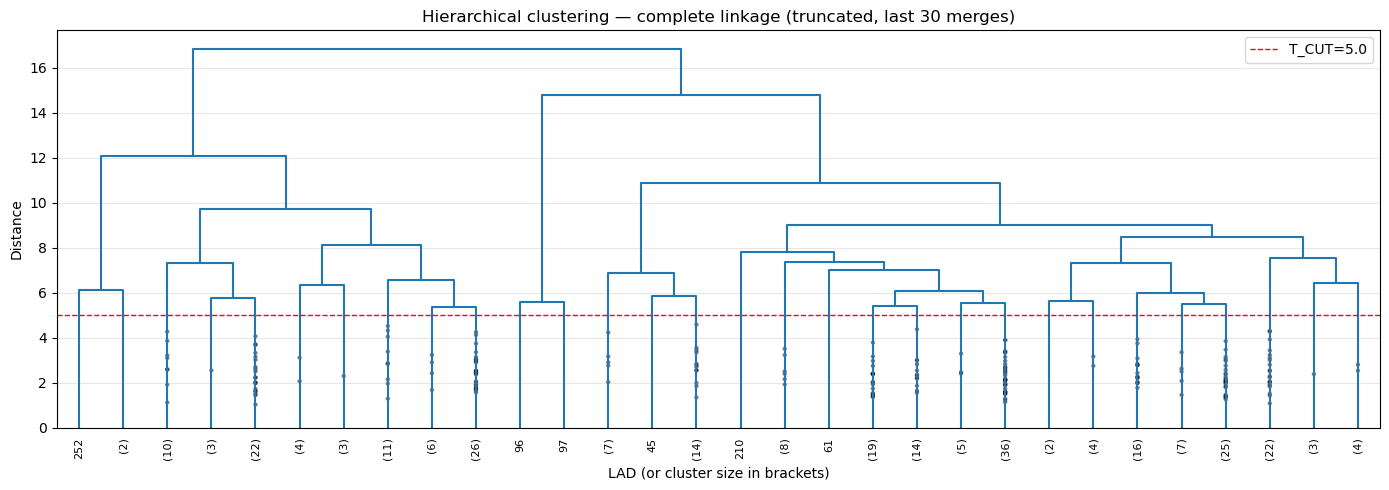

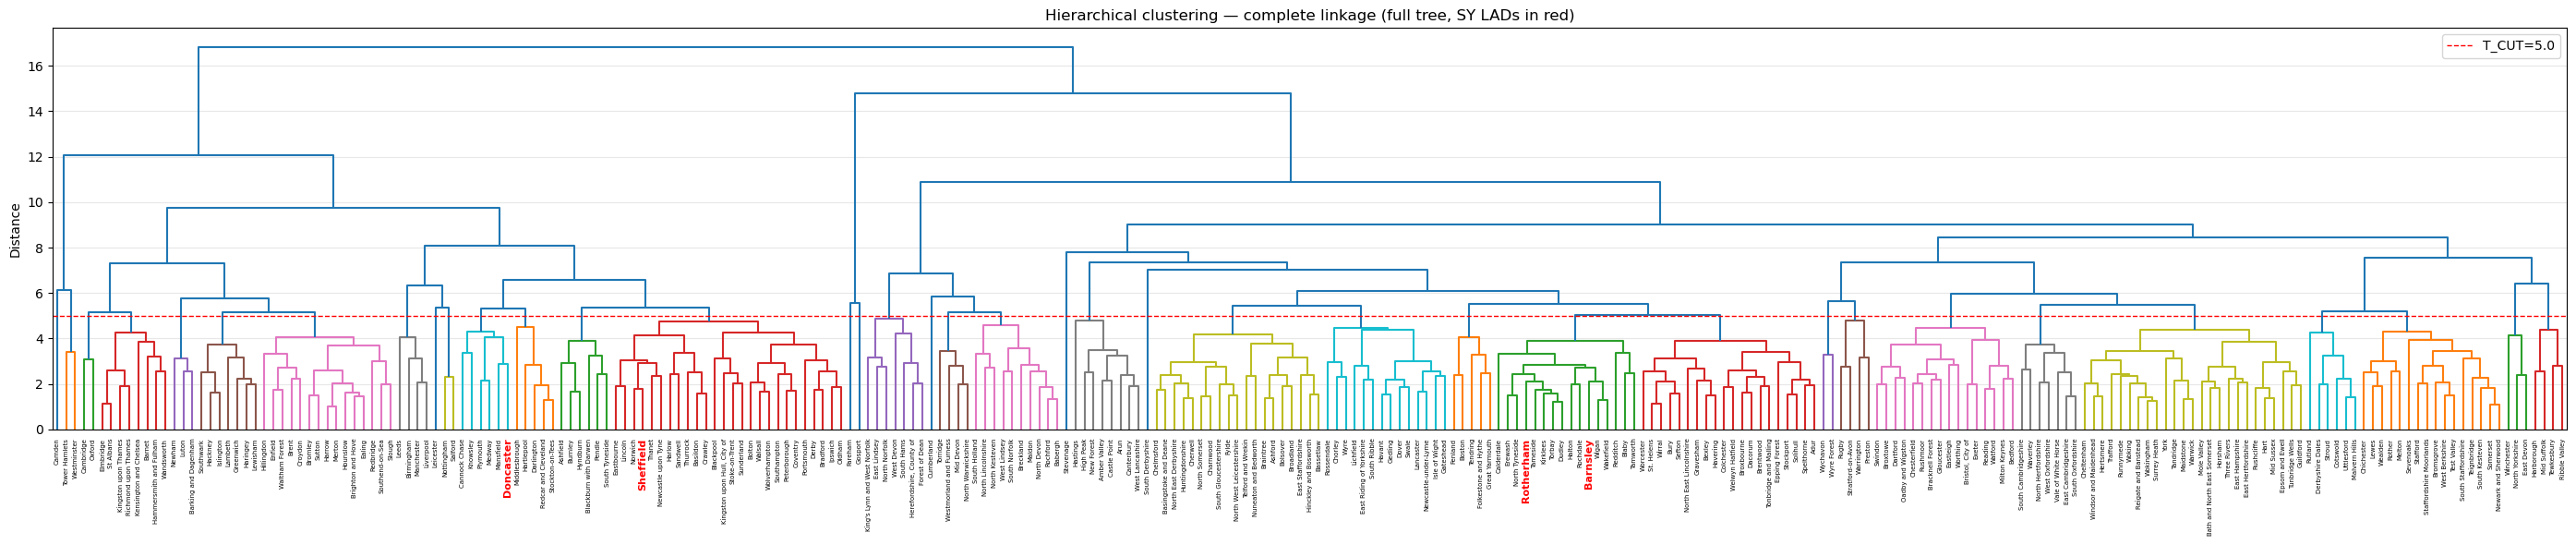

SY LADs positions in leaf order:
  Barnsley: leaf position 170/279
  Doncaster: leaf position 50/279
  Rotherham: leaf position 163/279
  Sheffield: leaf position 65/279


In [21]:
# ============================================================
# CELL 4b — Hierarchical clustering + dendrogram
#
# Complete linkage: clusters merged on maximum distance between
# any two points across clusters. Produces compact clusters —
# desirable for peer benchmarking.
# ============================================================

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

FOCUS_SECTORS = [
    "Advanced Manufacturing",
    "Creative Industries",
    "Digital and Technologies",
    "Financial Services",
    "Life Sciences",
    "Professional and Business Services",
]

T_CUT = 5.0  # distance threshold — adjust after inspecting dendrogram

# Build linkage matrix
Z = linkage(X, method="complete", metric="euclidean")

lad_names      = lad_df.index.tolist()
lad_labels     = lad_df["GEOGRAPHY_NAME"].tolist()
sy_indices     = [lad_names.index(c) for c in SY_CODES if c in lad_names]
sy_label_names = [lad_df.loc[c, "GEOGRAPHY_NAME"] for c in SY_CODES if c in lad_names]

# ── Plot 1: Truncated dendrogram (last 30 merges) ──────────────────
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(
    Z, ax=ax,
    truncate_mode="lastp", p=30,
    leaf_rotation=90, leaf_font_size=8,
    show_contracted=True,
    color_threshold=T_CUT,
)
ax.axhline(y=T_CUT, color="red", linestyle="--", linewidth=1, label=f"T_CUT={T_CUT}")
ax.set_title("Hierarchical clustering — complete linkage (truncated, last 30 merges)")
ax.set_xlabel("LAD (or cluster size in brackets)")
ax.set_ylabel("Distance")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../../output/graphs/franco/dendrogram_truncated.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Full dendrogram with SY LADs highlighted ──────────────
fig, ax = plt.subplots(figsize=(28, 6))
ddata = dendrogram(
    Z, ax=ax,
    labels=lad_labels,
    leaf_rotation=90, leaf_font_size=5,
    color_threshold=T_CUT,
)
for lbl in ax.get_xticklabels():
    if lbl.get_text() in sy_label_names:
        lbl.set_color("red")
        lbl.set_fontsize(8)
        lbl.set_fontweight("bold")
ax.axhline(y=T_CUT, color="red", linestyle="--", linewidth=1, label=f"T_CUT={T_CUT}")
ax.set_title("Hierarchical clustering — complete linkage (full tree, SY LADs in red)")
ax.set_ylabel("Distance")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../../output/graphs/franco/dendrogram_full.png", dpi=150, bbox_inches="tight")
plt.show()

print("SY LADs positions in leaf order:")
leaf_order = ddata["leaves"]
for idx in sy_indices:
    pos = leaf_order.index(idx)
    print(f"  {lad_df.iloc[idx]['GEOGRAPHY_NAME']}: leaf position {pos}/{len(lad_df)}")


In [22]:
# ============================================================
# CELL 4c — Cut the tree and find comparators
#
# Cut the dendrogram at T_CUT. For each SY LAD, identify
# cluster peers and find top performers (by lq_emp) per sector
# within the same cluster.
# ============================================================

# Assign clusters
lad_df["cluster"] = fcluster(Z, t=T_CUT, criterion="distance")

print(f"=== TREE CUT AT t={T_CUT} ===")
print(f"Number of clusters formed: {lad_df['cluster'].nunique()}")
print(f"\nCluster sizes (top 15 largest):")
for cid, cnt in lad_df["cluster"].value_counts().head(15).items():
    print(f"  Cluster {cid}: {cnt} LADs")

print(f"\n=== CLUSTER MEMBERSHIPS — SY LADs ===")
for code in SY_CODES:
    if code in lad_df.index:
        name    = lad_df.loc[code, "GEOGRAPHY_NAME"]
        cluster = lad_df.loc[code, "cluster"]
        size    = (lad_df["cluster"] == cluster).sum()
        print(f"  {name} ({code}): Cluster {cluster}  (n={size} LADs)")

# Build lq_lookup: latest year, one row per LAD×sector
lq_lookup = (
    panel[panel["YEAR"] == YEAR]
    .set_index(["GEOGRAPHY_CODE", "IS8_SECTOR"])[["lq_emp", "lq_bus"]]
)

print(f"\n=== COMPARATOR LADs — same cluster, higher lq_emp (top 5 per sector) ===")
for code in SY_CODES:
    if code not in lad_df.index:
        continue
    name        = lad_df.loc[code, "GEOGRAPHY_NAME"]
    cluster     = lad_df.loc[code, "cluster"]
    cluster_lads = lad_df[lad_df["cluster"] == cluster].index.tolist()

    print(f"\n{'='*60}")
    print(f"{name} (Cluster {cluster}, n={len(cluster_lads)} LADs)")
    print(f"Peers: {[lad_df.loc[c, 'GEOGRAPHY_NAME'] for c in cluster_lads if c != code]}")

    for sector in FOCUS_SECTORS:
        lq_sec = lq_lookup.xs(sector, level="IS8_SECTOR")
        sy_lq  = lq_sec.loc[code, "lq_emp"] if code in lq_sec.index else None

        comparators = (
            lq_sec.reindex(cluster_lads)
            .dropna(subset=["lq_emp"])
            .sort_values("lq_emp", ascending=False)
        )
        comparators = comparators[
            (comparators.index != code) &
            (comparators["lq_emp"] > (float(sy_lq) if sy_lq is not None else 0))
        ].head(5)

        sy_str = f"{float(sy_lq):.2f}" if sy_lq is not None else "N/A"
        print(f"\n  [{sector}] — {name} lq_emp: {sy_str}")
        if len(comparators) == 0:
            print("    No comparators with higher lq_emp in same cluster")
        else:
            print(f"    {'LAD':<30} {'lq_emp':>8} {'lq_bus':>8}")
            for comp_code, comp_row in comparators.iterrows():
                comp_name = lad_df.loc[comp_code, "GEOGRAPHY_NAME"] if comp_code in lad_df.index else comp_code
                print(f"    {comp_name:<30} {float(comp_row['lq_emp']):>8.2f} {float(comp_row['lq_bus']):>8.2f}")

=== TREE CUT AT t=5.0 ===
Number of clusters formed: 37

Cluster sizes (top 15 largest):
  Cluster 14: 26 LADs
  Cluster 33: 25 LADs
  Cluster 26: 20 LADs
  Cluster 22: 19 LADs
  Cluster 25: 16 LADs
  Cluster 31: 16 LADs
  Cluster 35: 16 LADs
  Cluster 7: 15 LADs
  Cluster 23: 14 LADs
  Cluster 19: 10 LADs
  Cluster 21: 8 LADs
  Cluster 4: 8 LADs
  Cluster 17: 7 LADs
  Cluster 32: 7 LADs
  Cluster 6: 7 LADs

=== CLUSTER MEMBERSHIPS — SY LADs ===
  Barnsley (E08000016): Cluster 25  (n=16 LADs)
  Doncaster (E08000017): Cluster 11  (n=6 LADs)
  Rotherham (E08000018): Cluster 25  (n=16 LADs)
  Sheffield (E08000019): Cluster 14  (n=26 LADs)

=== COMPARATOR LADs — same cluster, higher lq_emp (top 5 per sector) ===

Barnsley (Cluster 25, n=16 LADs)
Peers: ['Halton', 'Torbay', 'Erewash', 'Blaby', 'Tamworth', 'Redditch', 'Rochdale', 'Tameside', 'Wigan', 'Rotherham', 'North Tyneside', 'Dudley', 'Calderdale', 'Kirklees', 'Wakefield']

  [Advanced Manufacturing] — Barnsley lq_emp: 0.76
    LAD    

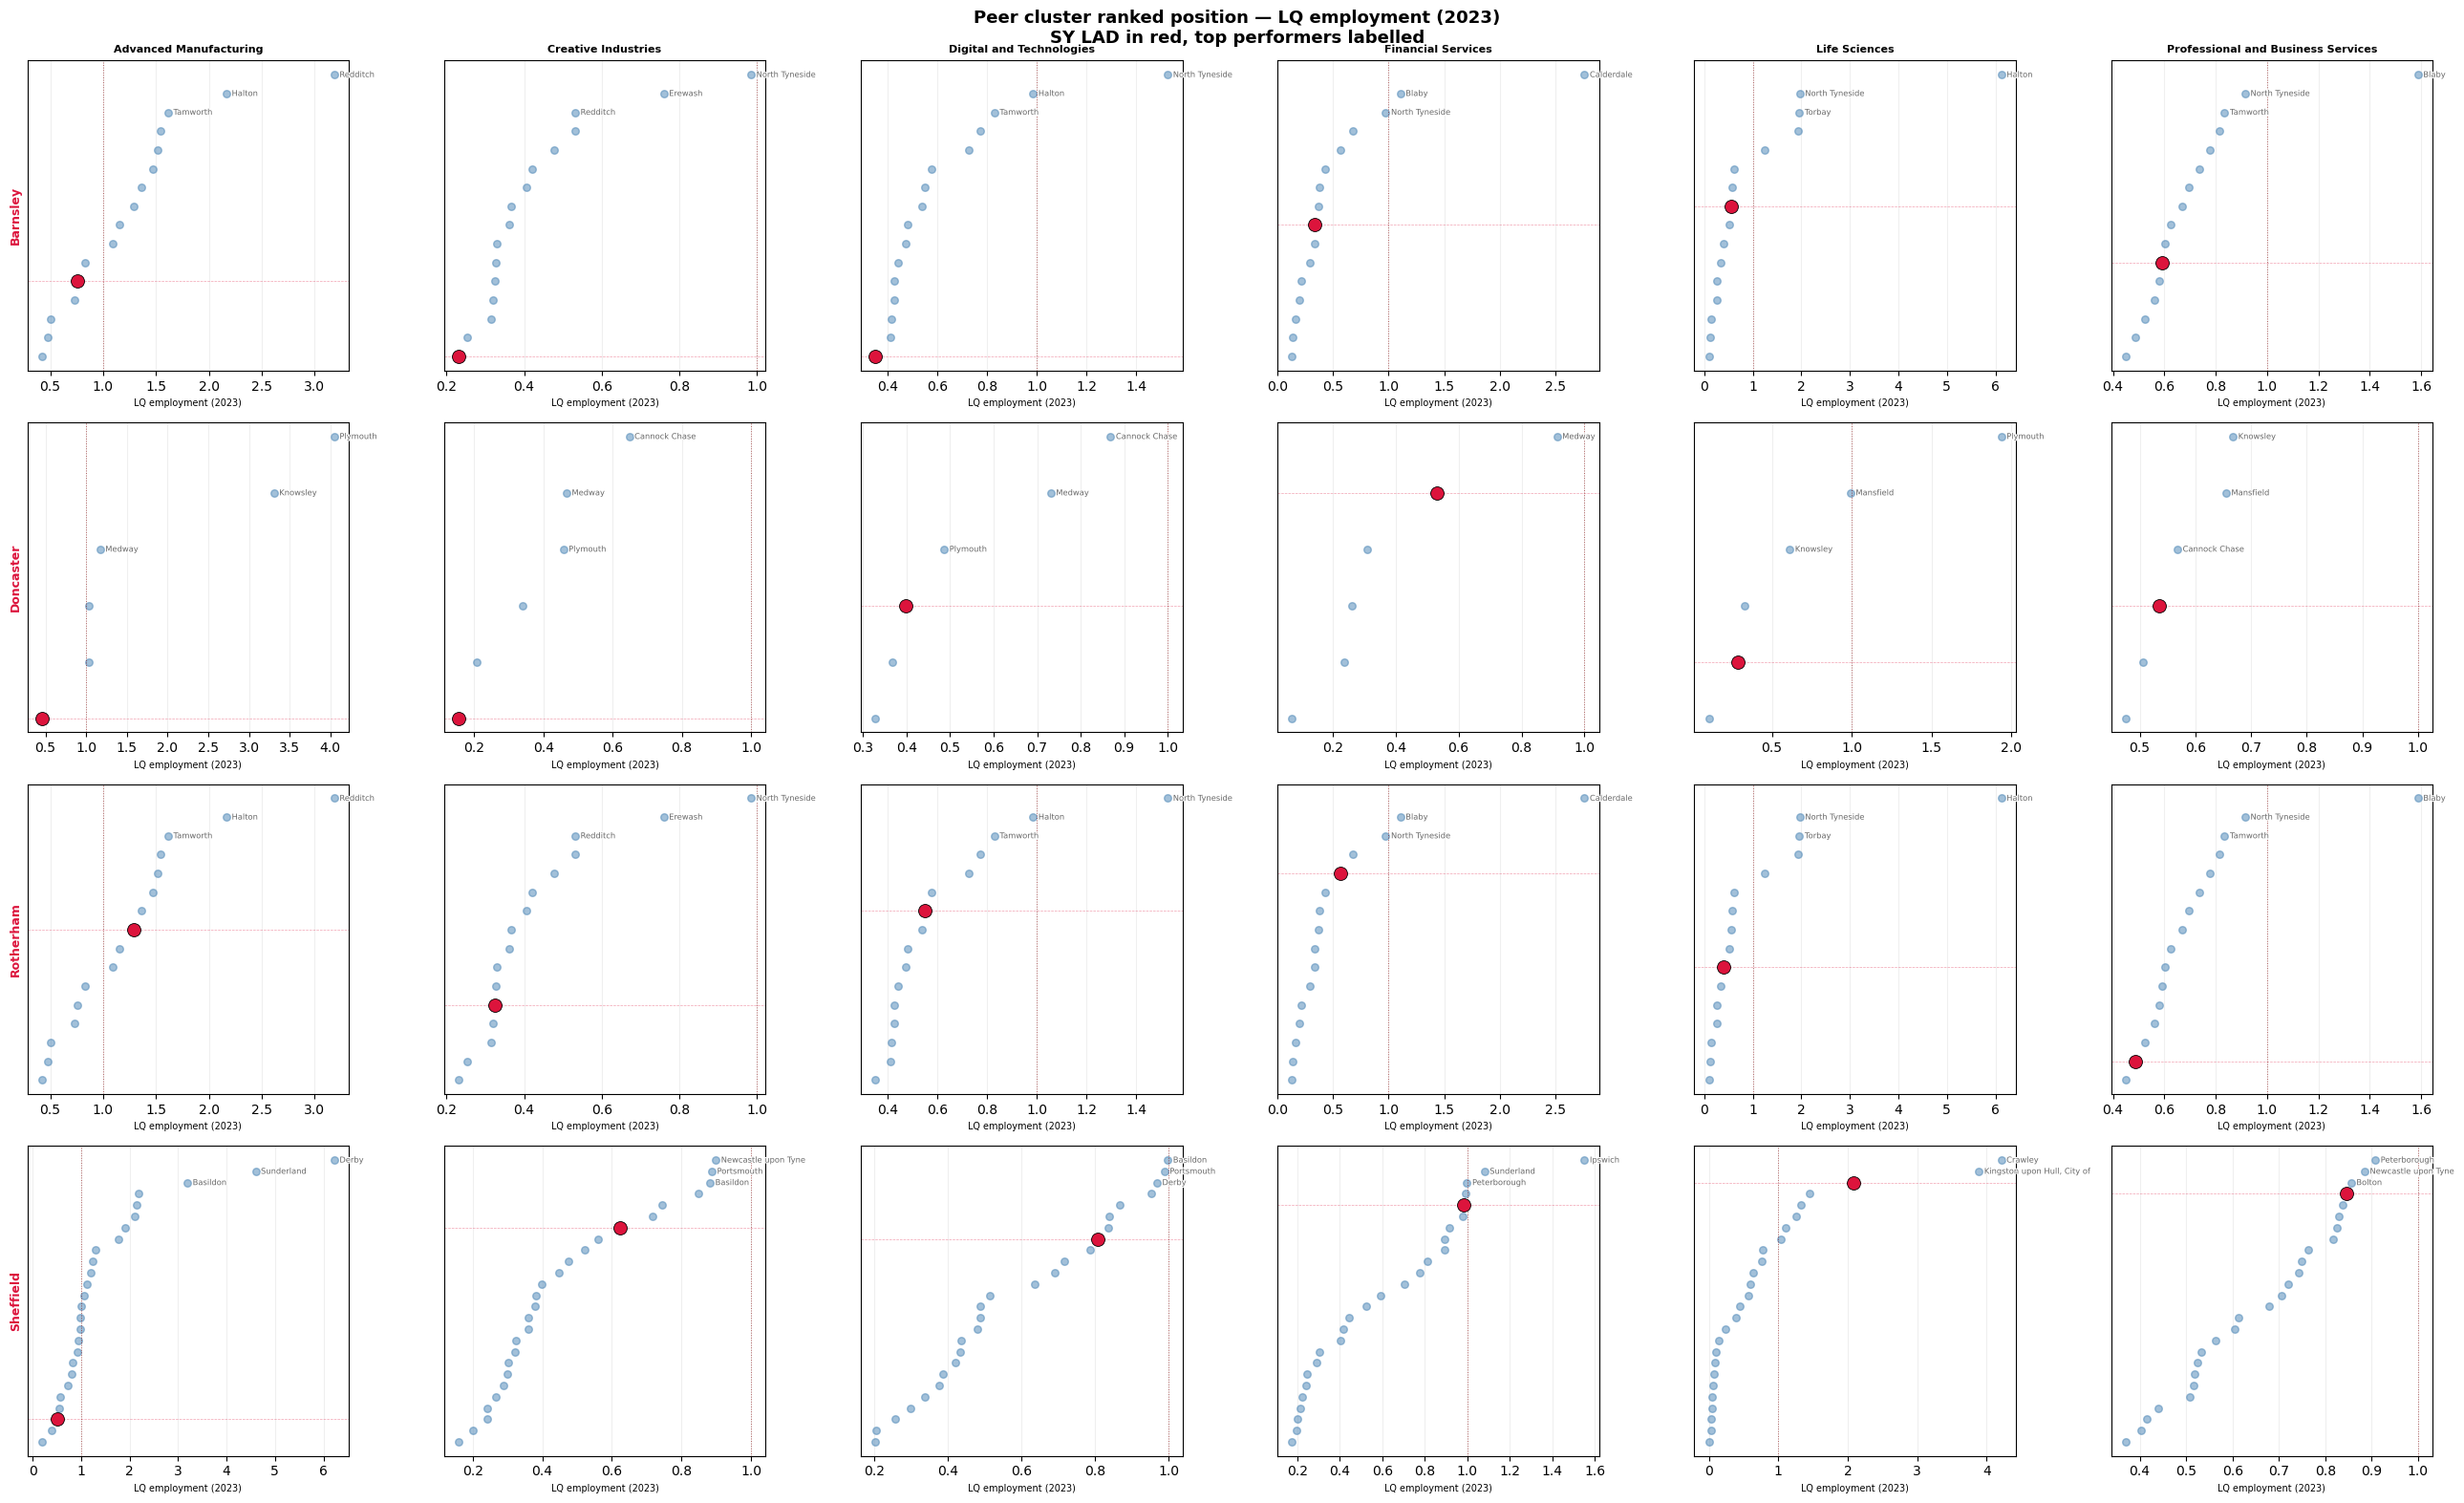

Saved: ../../output/graphs/franco/ranked_position_lq_emp.png


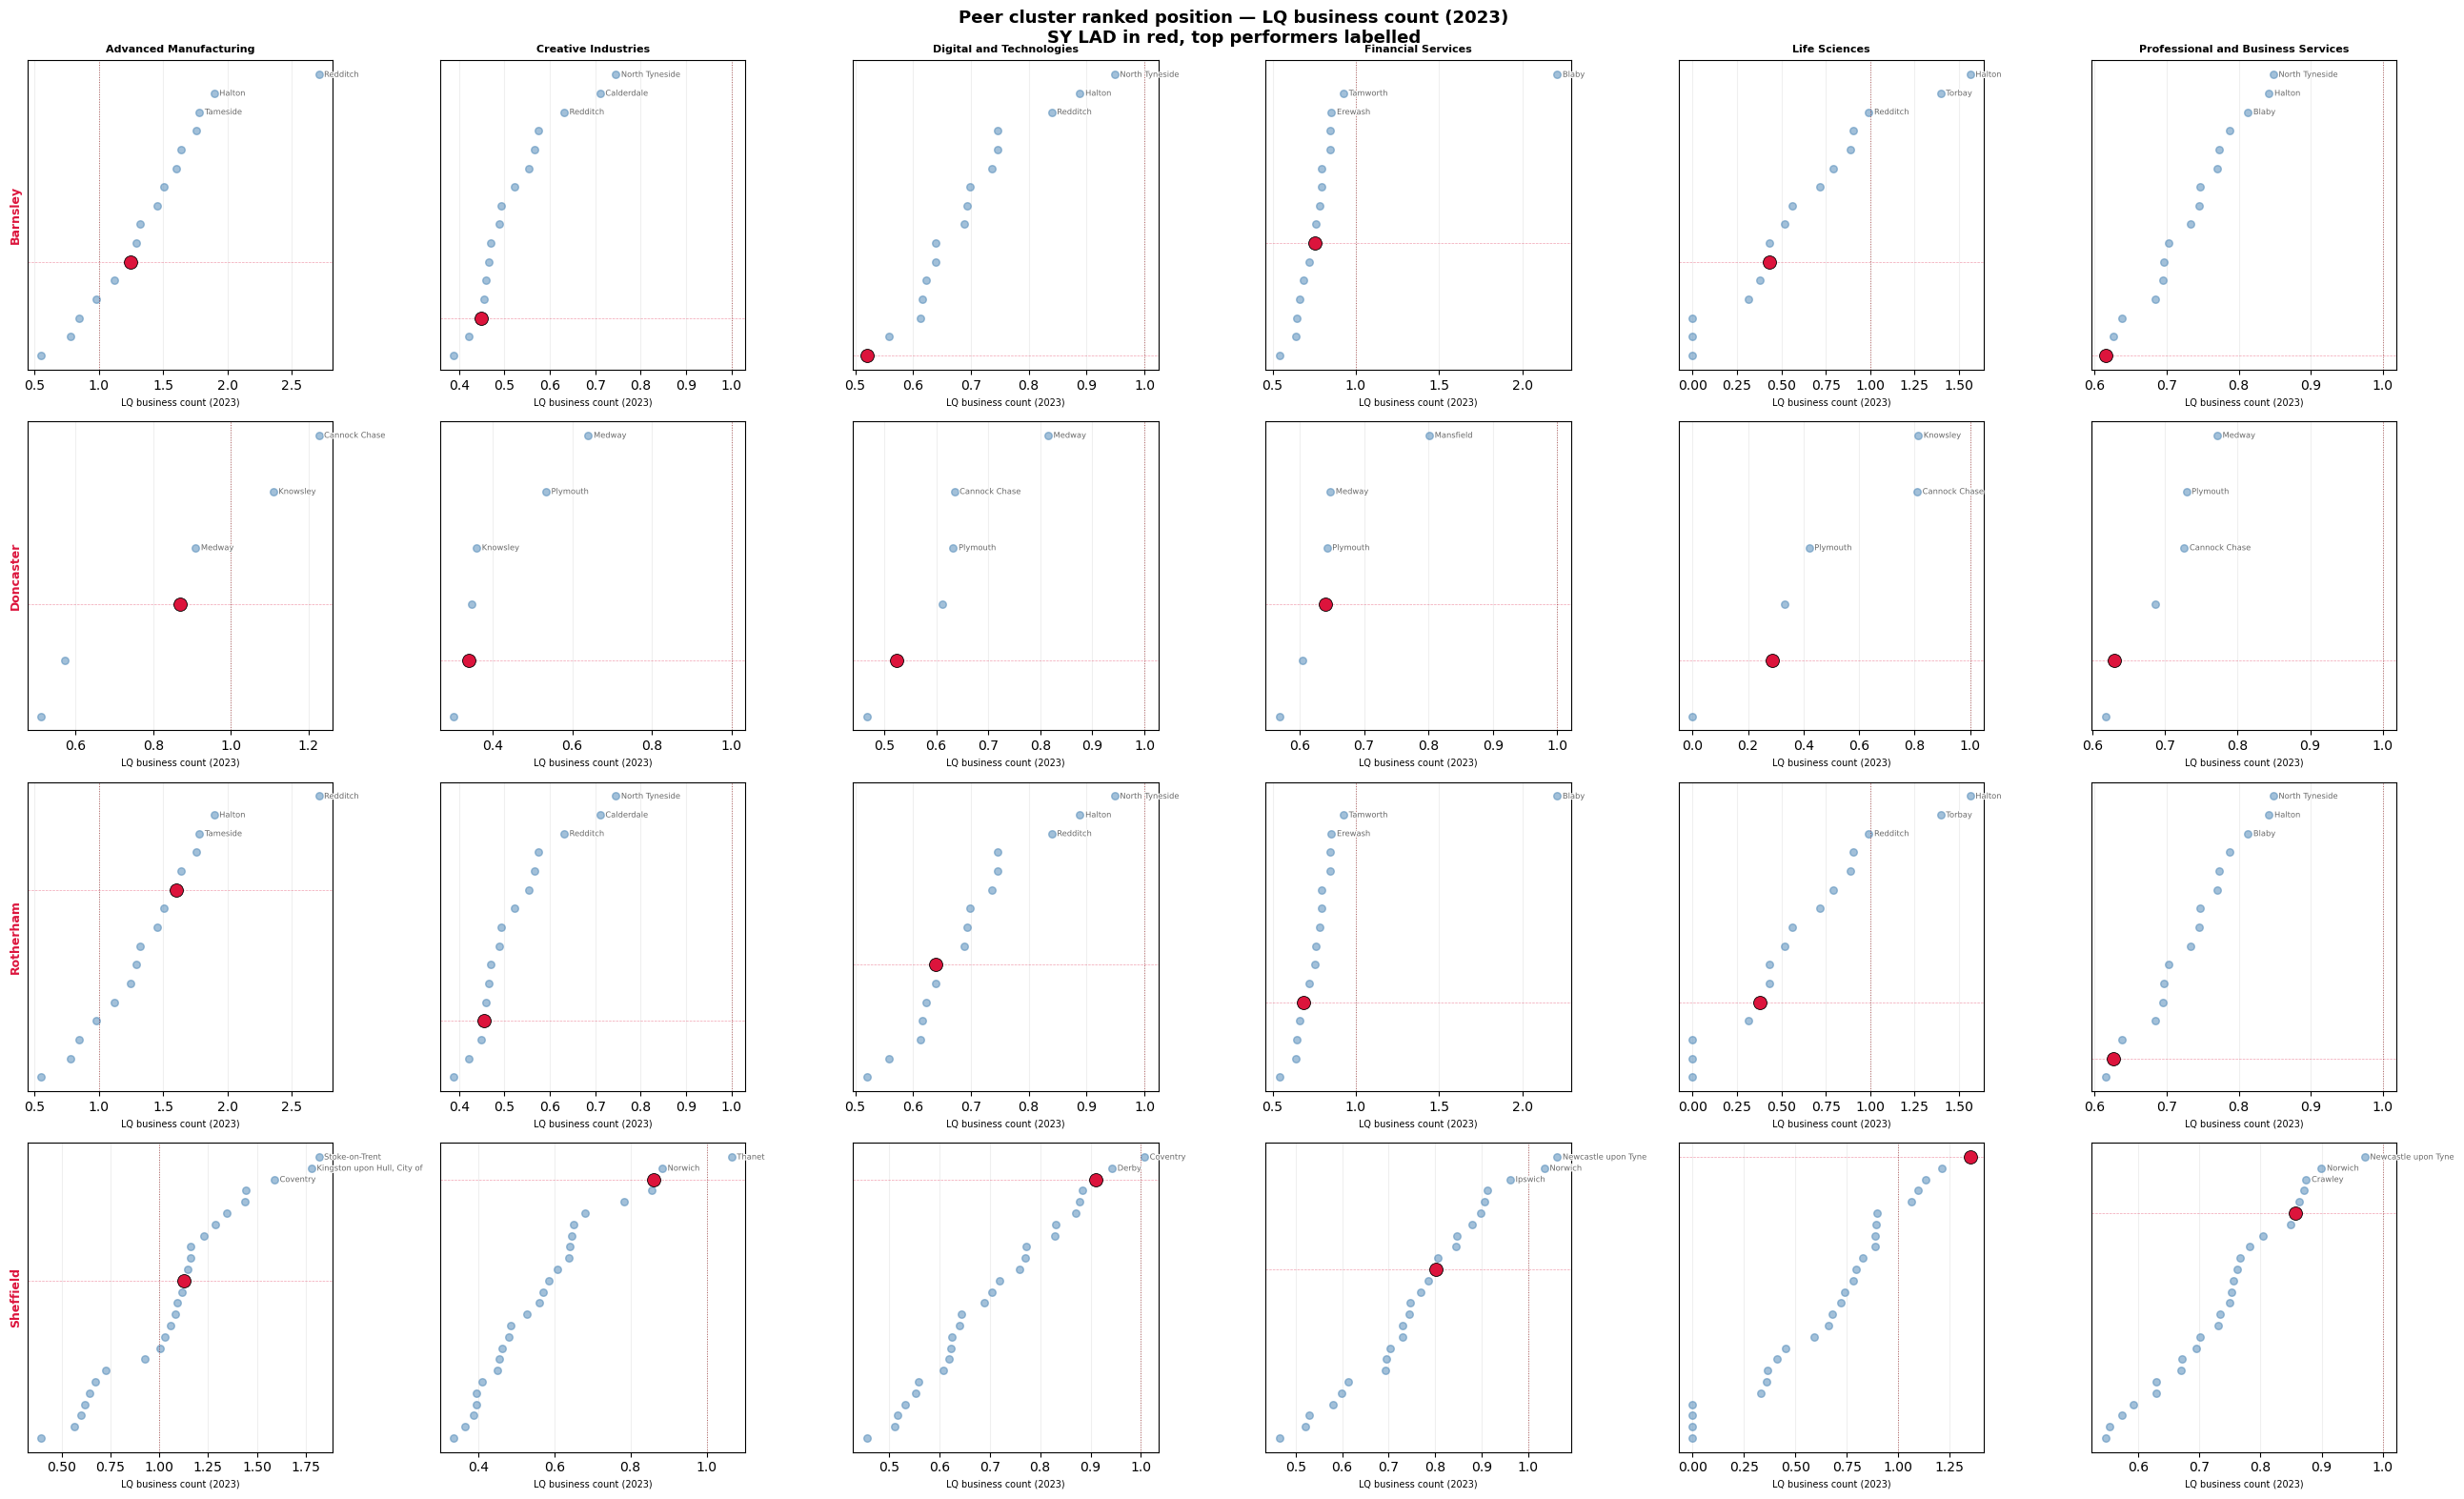

Saved: ../../output/graphs/franco/ranked_position_lq_bus.png


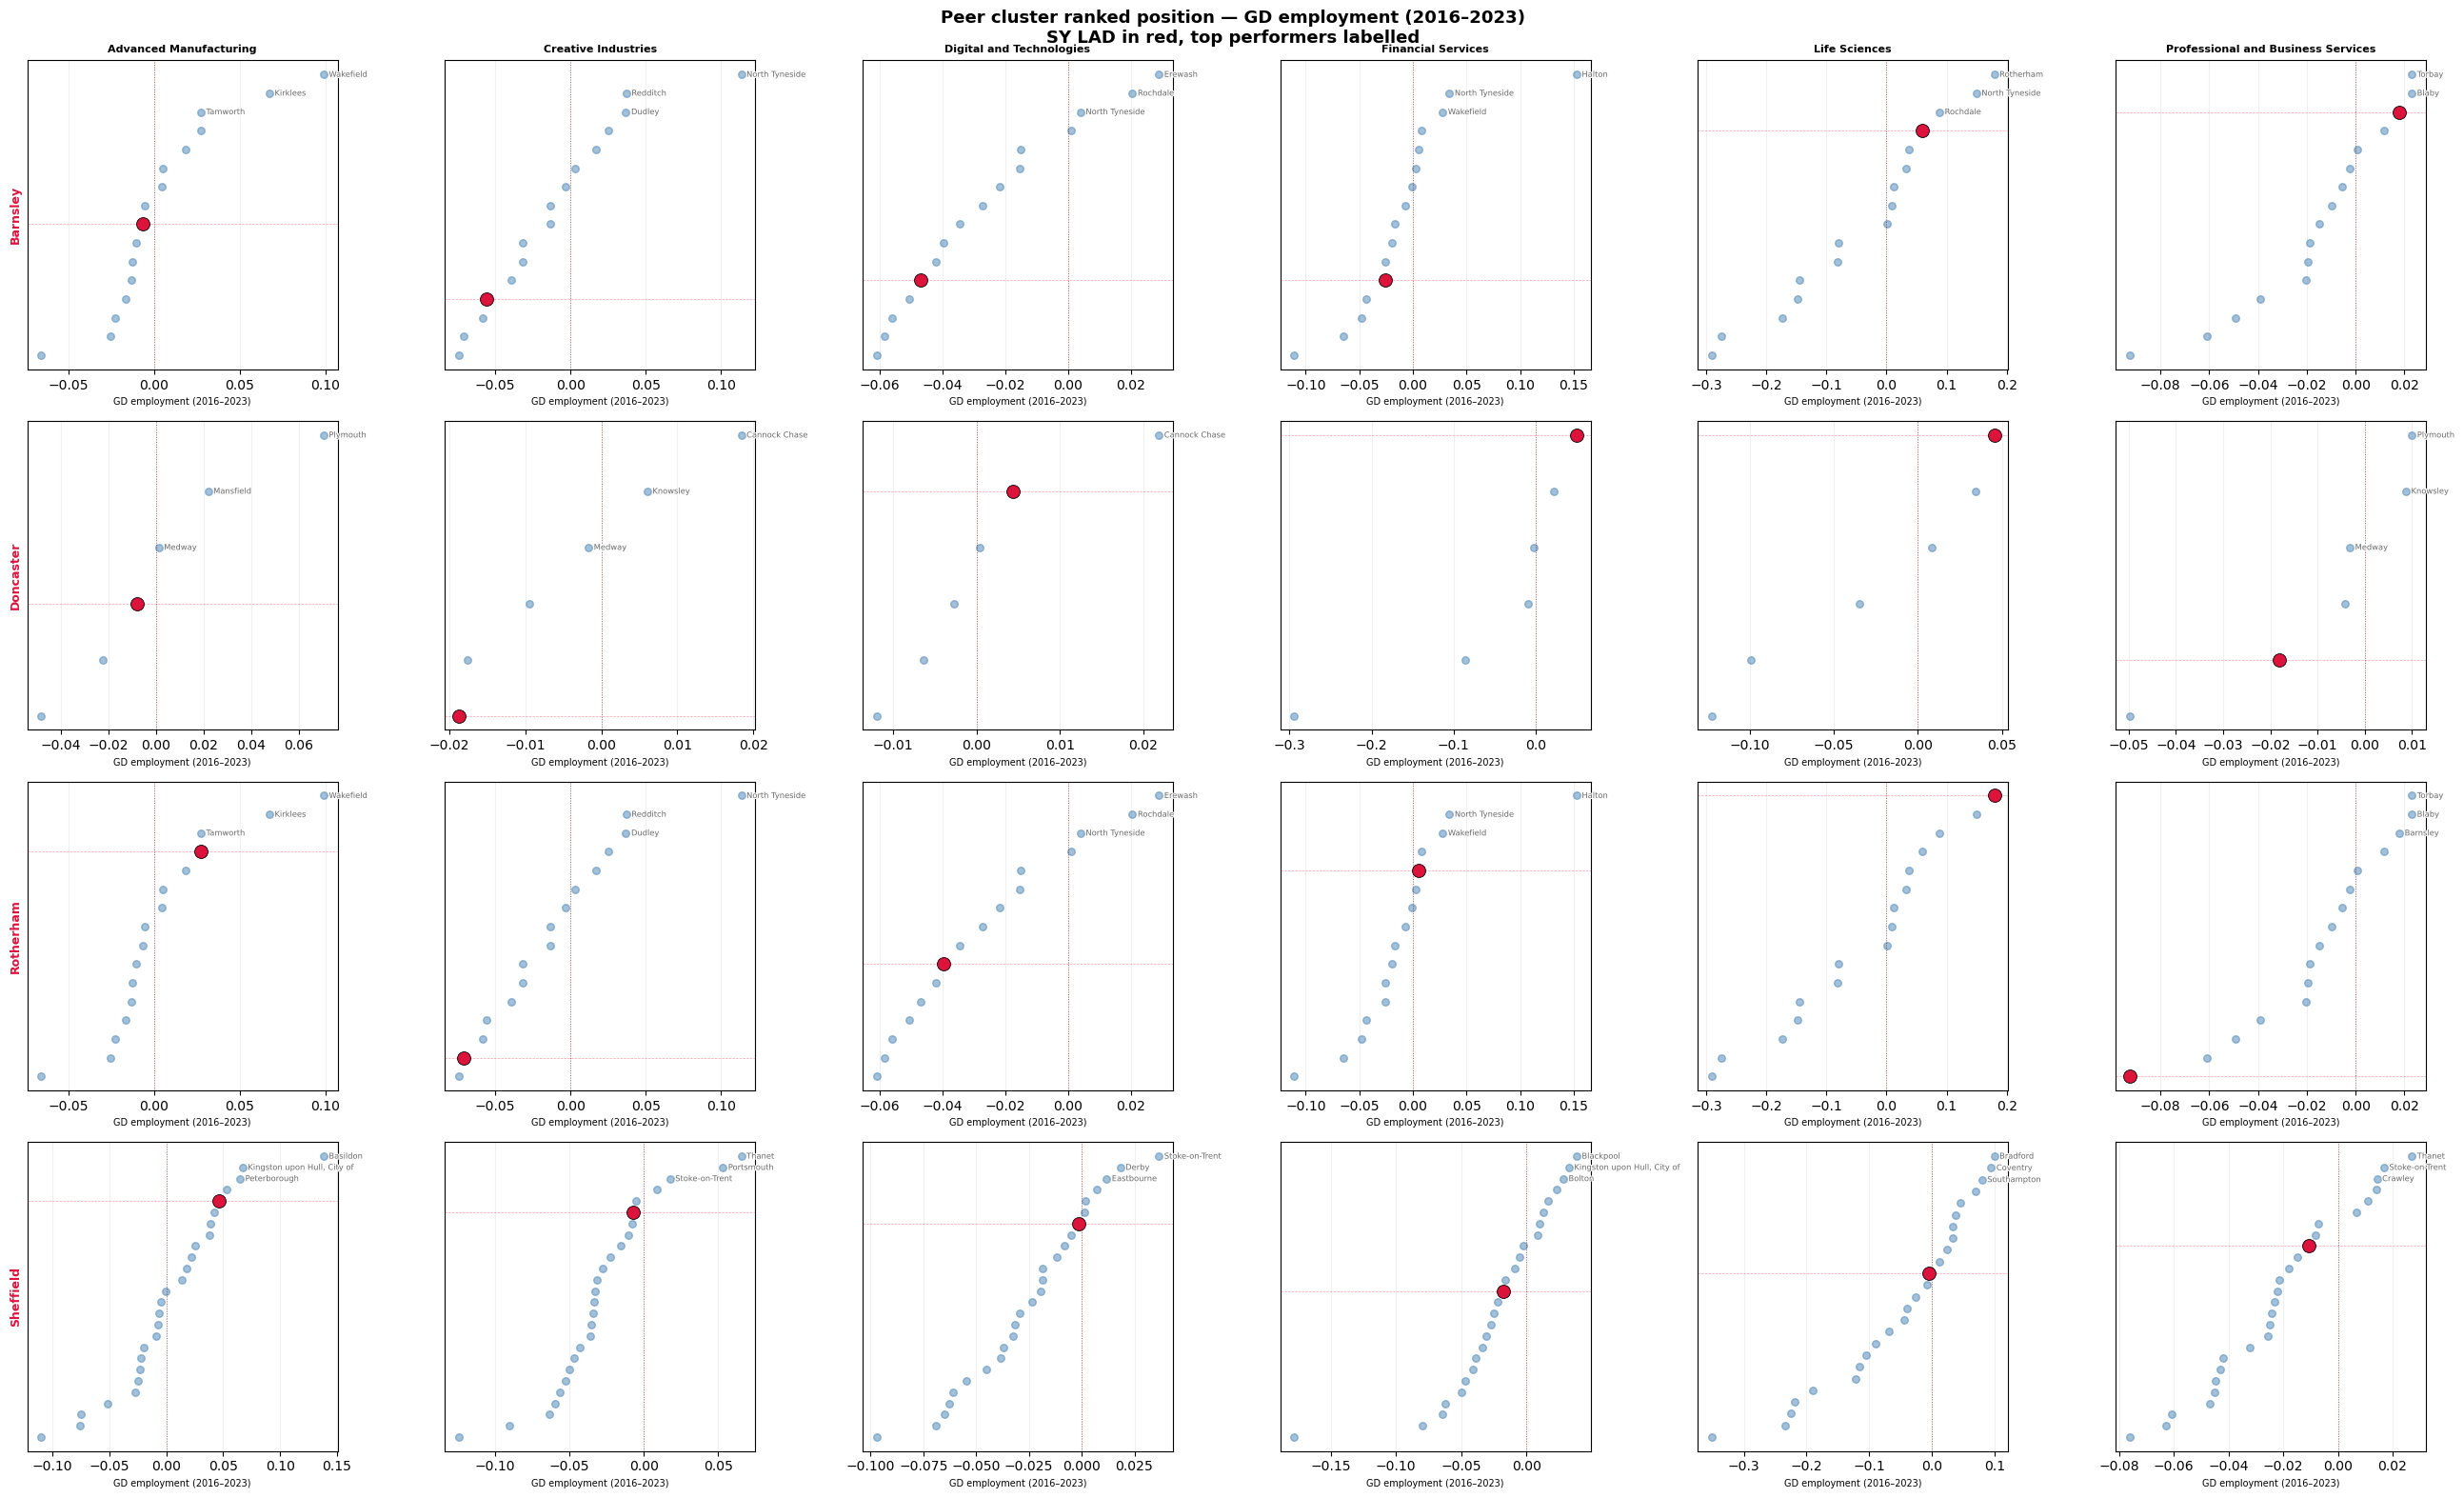

Saved: ../../output/graphs/franco/ranked_position_gd_emp.png


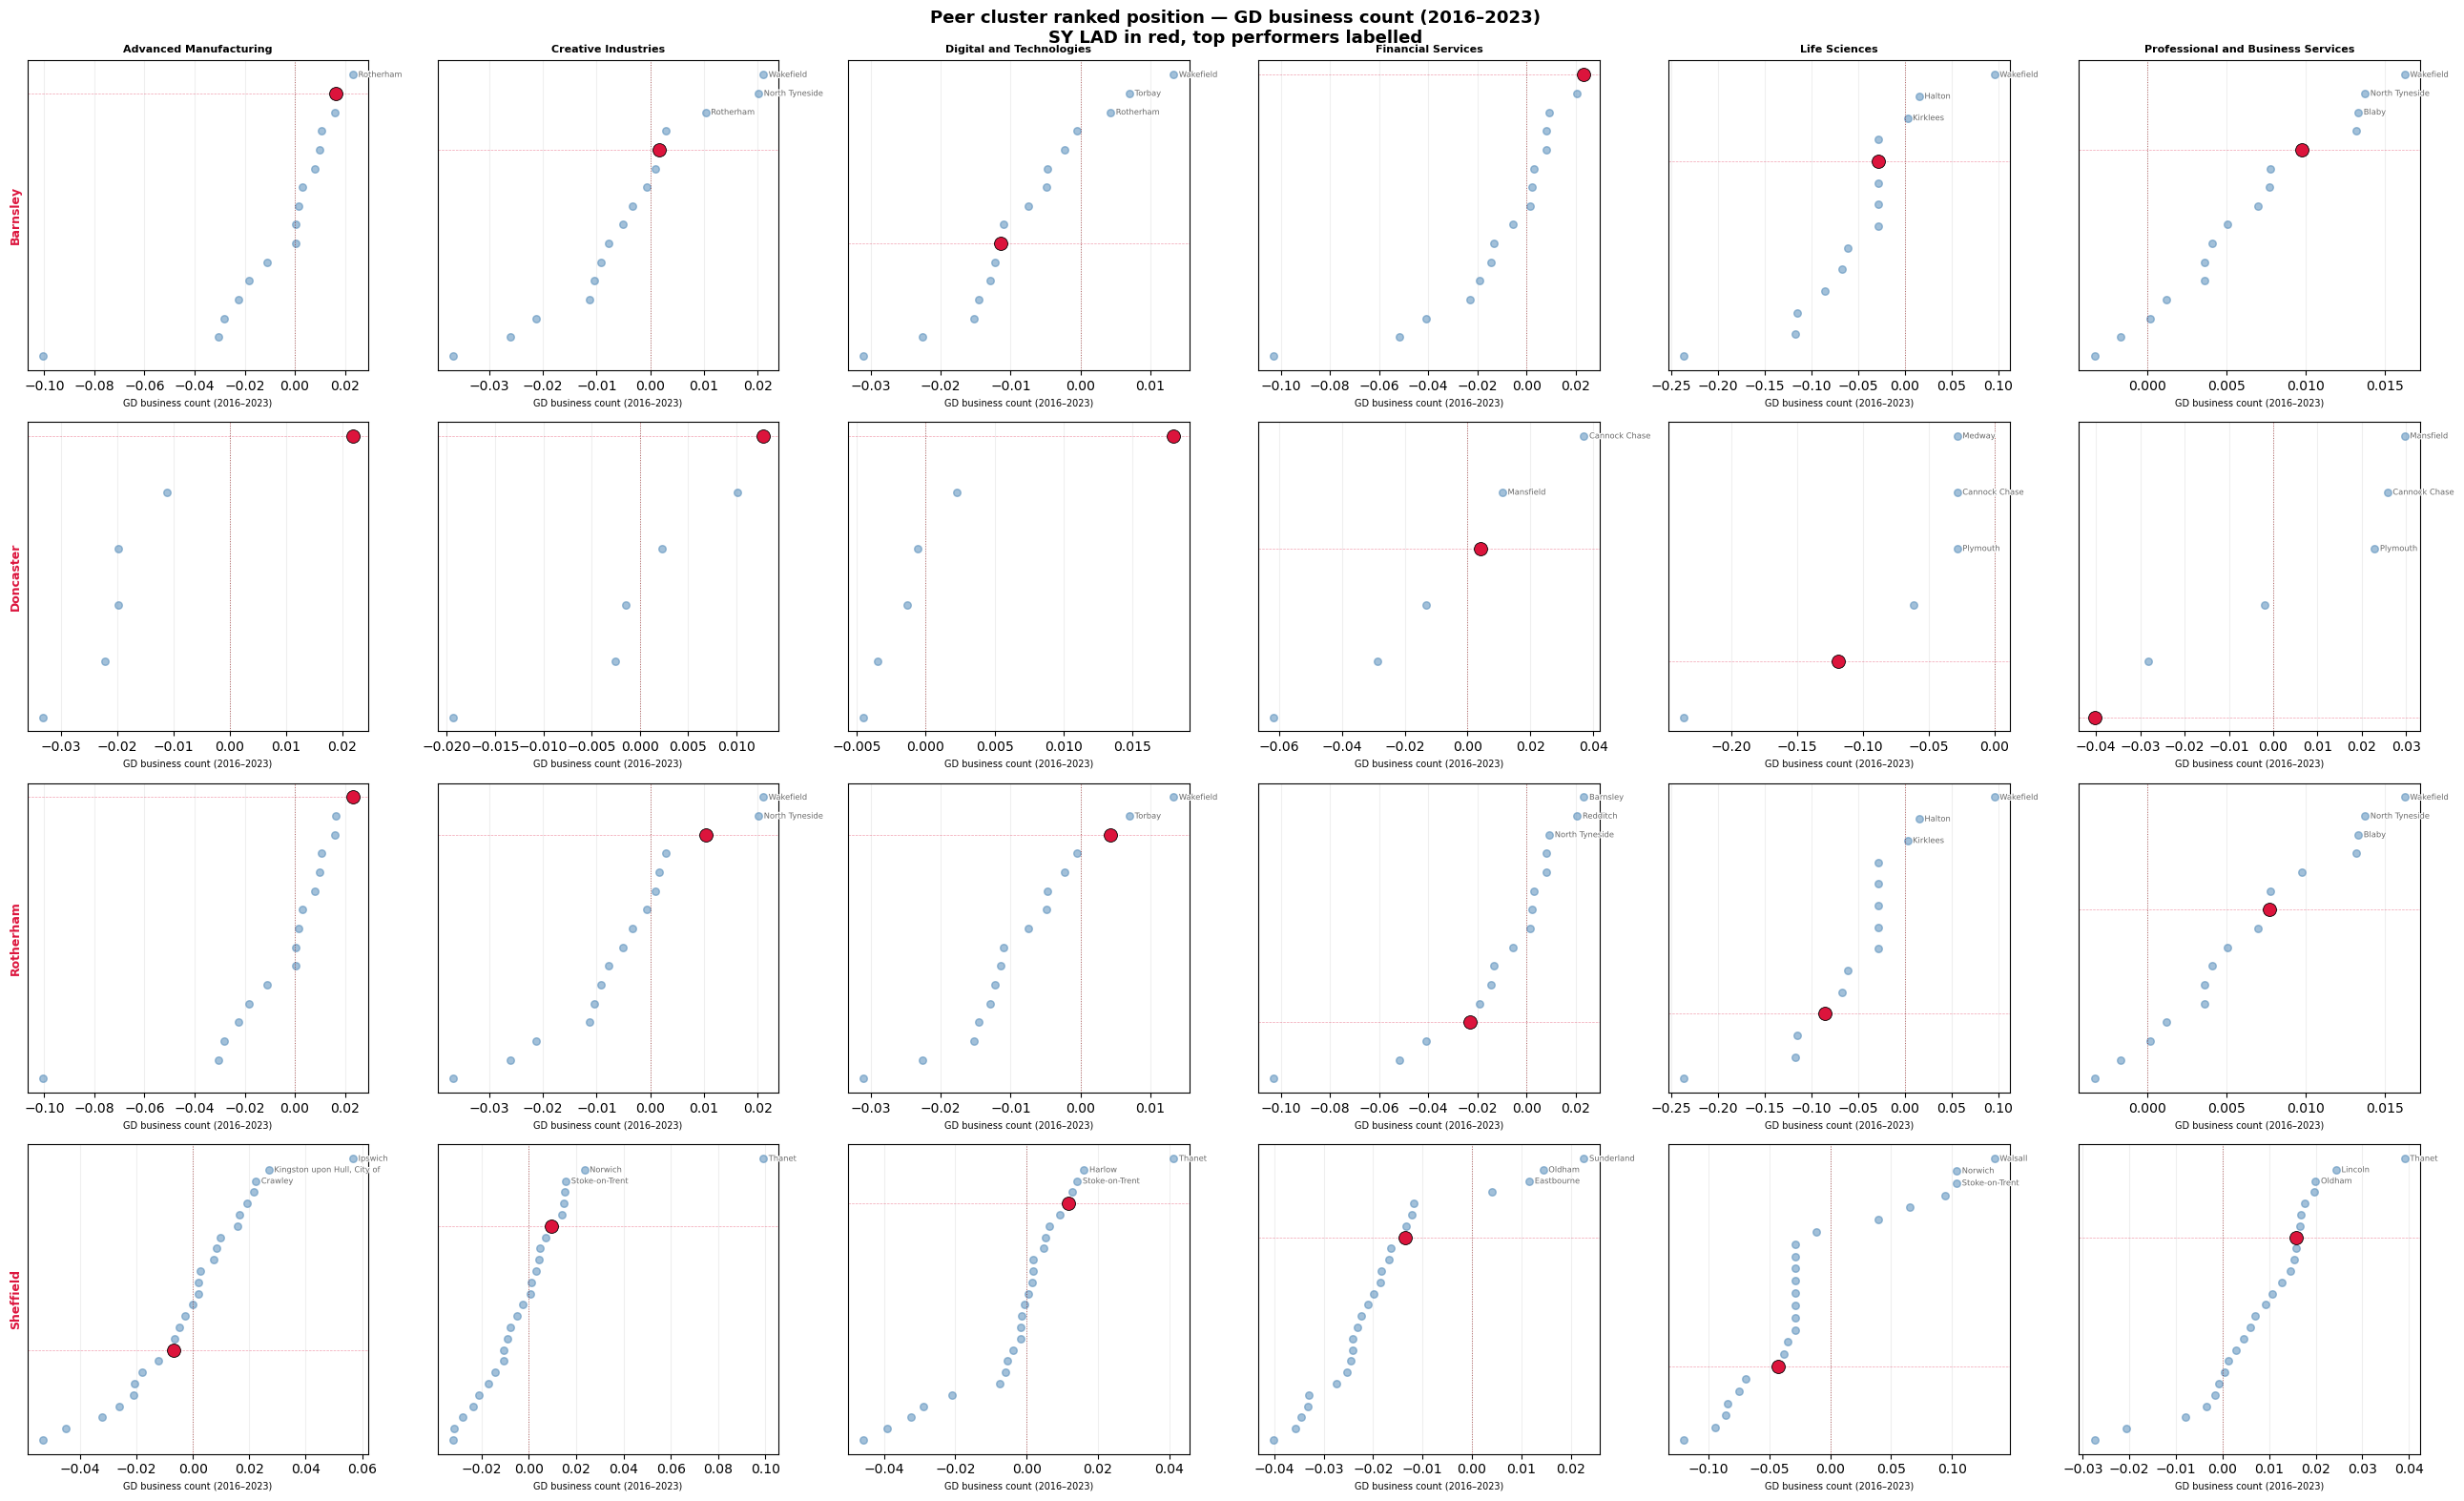

Saved: ../../output/graphs/franco/ranked_position_gd_bus.png


In [25]:
# ============================================================
# CELL 5b — Ranked peer position plots
#
# For each Y metric, produces one figure with:
#   4 rows (one per SY LAD) × 6 cols (one per sector)
# Each panel: horizontal dot plot of all cluster members
# ranked by metric value, SY LAD highlighted in red.
# Shows where each SY LAD sits in its peer distribution
# and the gap to top performers.
# ============================================================

import os
import matplotlib.patheffects as pe

OUTPUT_DIR = "../../output/graphs/franco"
os.makedirs(OUTPUT_DIR, exist_ok=True)

METRICS = [
    ("lq_emp",  f"LQ employment ({YEAR})"),
    ("lq_bus",  f"LQ business count ({YEAR})"),
    ("gd_emp",  f"GD employment (2016–{YEAR})"),
    ("gd_bus",  f"GD business count (2016–{YEAR})"),
]

SY_CLUSTER_IDS = sorted(lad_df.loc[lad_df.index.intersection(SY_CODES), "cluster"].unique())

for metric, metric_label in METRICS:
    fig, axes = plt.subplots(4, 6, figsize=(26, 16))
    fig.suptitle(
        f"Peer cluster ranked position — {metric_label}\nSY LAD in red, top performers labelled",
        fontsize=13, fontweight="bold"
    )

    ref_val = 1.0 if metric in ["lq_emp", "lq_bus"] else 0.0
    ref_lbl = "LQ=1" if metric in ["lq_emp", "lq_bus"] else "GD=0"

    for row, sy_code in enumerate(SY_CODES):
        if sy_code not in lad_df.index:
            continue
        sy_name   = lad_df.loc[sy_code, "GEOGRAPHY_NAME"]
        sy_cluster = lad_df.loc[sy_code, "cluster"]
        cluster_codes = lad_df[lad_df["cluster"] == sy_cluster].index.tolist()

        for col, sector in enumerate(FOCUS_SECTORS):
            ax = axes[row, col]

            # Get metric values for all cluster members
            if metric in ["lq_emp", "lq_bus"]:
                m_series = (
                    lq_lookup.xs(sector, level="IS8_SECTOR")[metric]
                    .reindex(cluster_codes)
                    .astype(float)
                )
            else:
                m_series = (
                    panel[(panel["YEAR"] == YEAR) &
                          (panel["IS8_SECTOR"] == sector)]
                    .set_index("GEOGRAPHY_CODE")[metric]
                    .astype(float)
                    .reindex(cluster_codes)
                )

            m_series = m_series.dropna().sort_values()
            names    = [lad_df.loc[c, "GEOGRAPHY_NAME"]
                        if c in lad_df.index else c
                        for c in m_series.index]
            vals     = m_series.values
            is_sy    = np.array([c == sy_code for c in m_series.index])

            y_pos = np.arange(len(vals))

            # Peer dots
            ax.scatter(vals[~is_sy], y_pos[~is_sy],
                       color="steelblue", alpha=0.5, s=30, zorder=2)

            # SY LAD dot
            if is_sy.any():
                ax.scatter(vals[is_sy], y_pos[is_sy],
                           color="crimson", s=100, zorder=5,
                           edgecolors="black", linewidths=0.6)
                ax.axhline(y_pos[is_sy][0], color="crimson",
                           linewidth=0.5, linestyle="--", alpha=0.4)

            # Label top 3 peers above SY
            sy_val = vals[is_sy][0] if is_sy.any() else -np.inf
            top_mask = (vals > sy_val) & (~is_sy)
            top_idx  = np.where(top_mask)[0][-3:] if top_mask.sum() >= 3 \
                       else np.where(top_mask)[0]
            for i in top_idx:
                ax.annotate(names[i], (vals[i], y_pos[i]),
                            xytext=(4, 0), textcoords="offset points",
                            fontsize=6, color="dimgrey", va="center",
                            path_effects=[pe.withStroke(linewidth=1.5,
                                                        foreground="white")])

            # Reference line
            ax.axvline(ref_val, color="darkred", linewidth=0.7,
                       linestyle=":", alpha=0.6)

            ax.set_yticks([])
            ax.set_xlabel(metric_label, fontsize=7)
            ax.grid(axis="x", alpha=0.2)

            if col == 0:
                ax.set_ylabel(sy_name, fontsize=9,
                              fontweight="bold", color="crimson")
            if row == 0:
                ax.set_title(sector, fontsize=8, fontweight="bold")

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/ranked_position_{metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

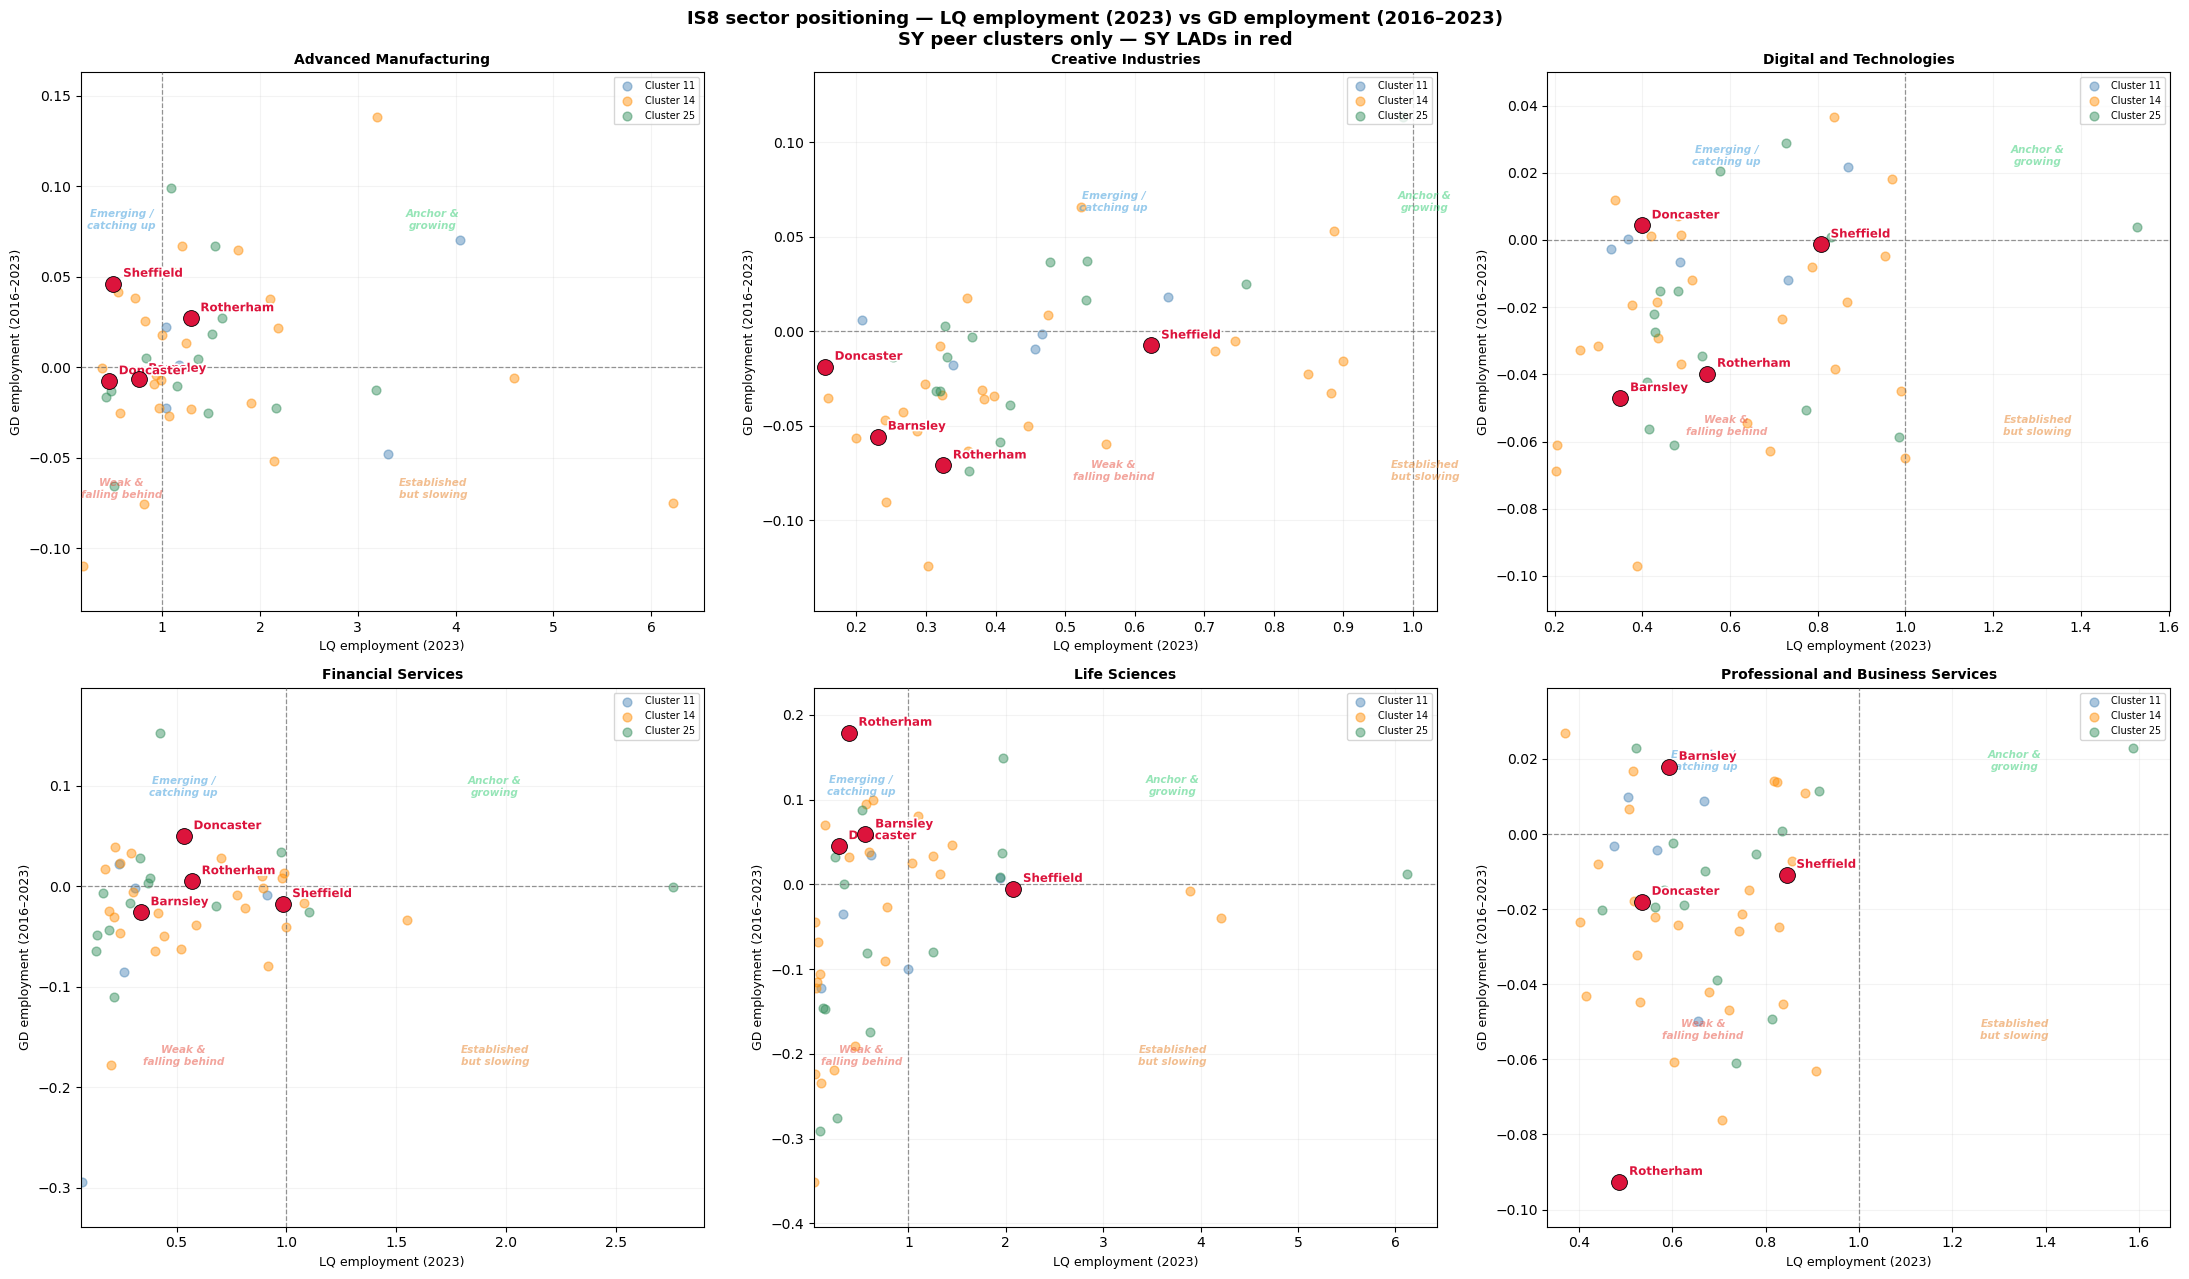

Saved: ../../output/graphs/franco/quadrant_lq_emp_vs_gd_emp.png


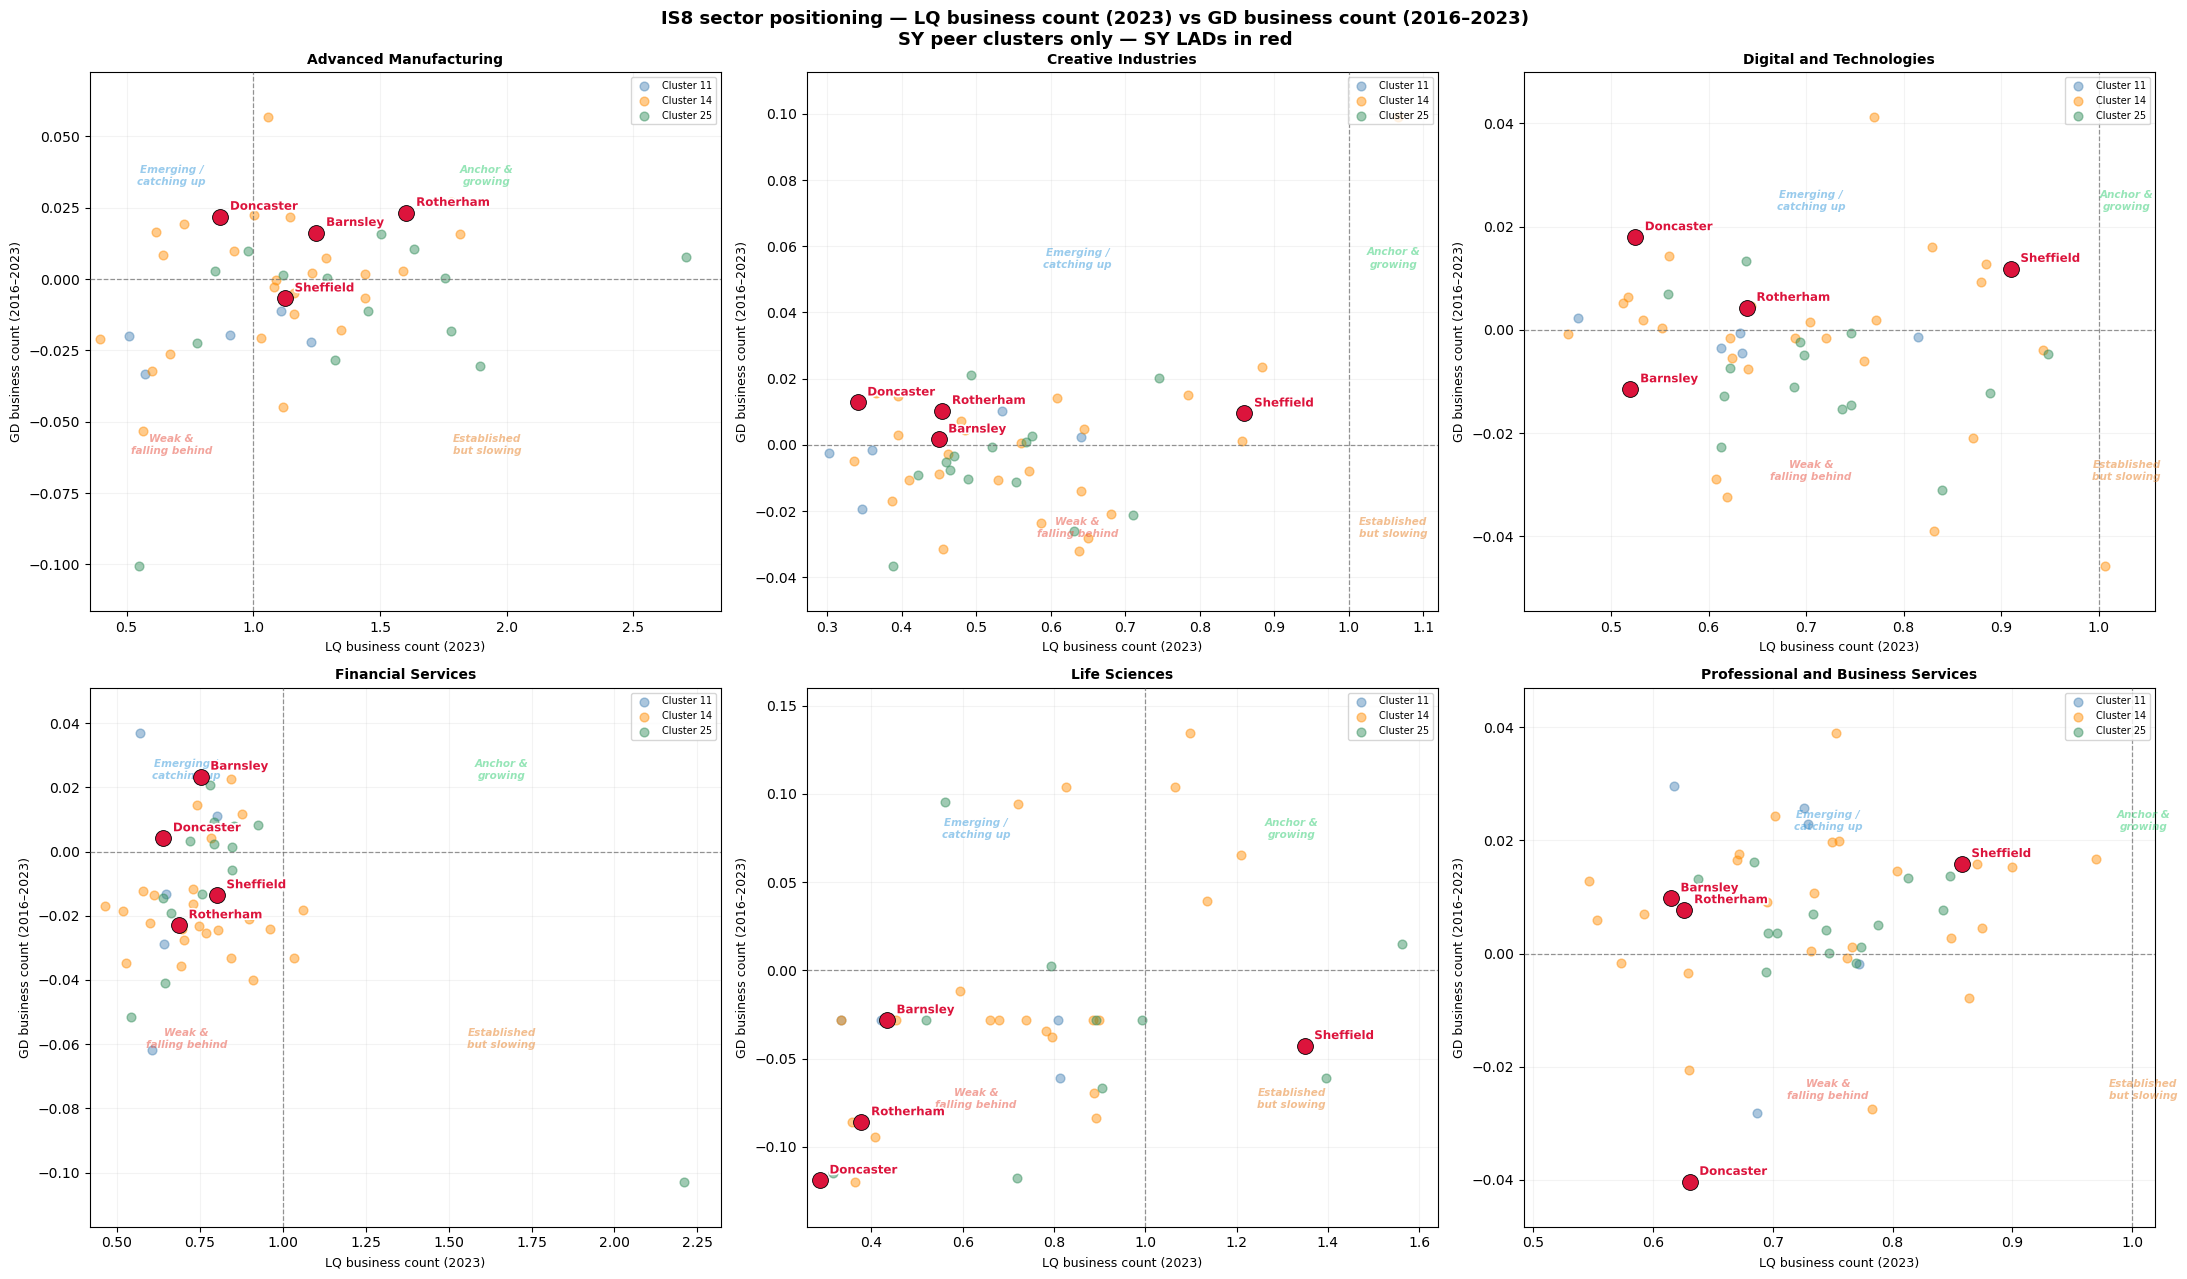

Saved: ../../output/graphs/franco/quadrant_lq_bus_vs_gd_bus.png


In [28]:
# ============================================================
# CELL 5c — IS8 sector quadrant positioning
#
# Plots LQ (x) vs GD (y) for all LADs in SY peer clusters.
# Quadrant boundaries: LQ=1 (national avg), GD=0 (national trend)
# 2×3 grid — one panel per IS8 sector.
# Runs twice: once for emp, once for bus.
# ============================================================

METRIC_PAIRS = [
    ("lq_emp", "gd_emp",
     f"LQ employment ({YEAR})", f"GD employment (2016–{YEAR})"),
    ("lq_bus", "gd_bus",
     f"LQ business count ({YEAR})", f"GD business count (2016–{YEAR})"),
]

QUADRANT_LABELS = {
    "Q1": ("Anchor &\ngrowing",        "top-right",    "#2ecc71"),
    "Q2": ("Emerging /\ncatching up",  "top-left",     "#3498db"),
    "Q3": ("Weak &\nfalling behind",   "bottom-left",  "#e74c3c"),
    "Q4": ("Established\nbut slowing", "bottom-right", "#e67e22"),
}

# Derive SY cluster IDs and colours dynamically
SY_CLUSTER_IDS  = sorted(lad_df.loc[lad_df.index.intersection(SY_CODES), "cluster"].unique())
cluster_colours = {cid: c for cid, c in zip(SY_CLUSTER_IDS, ["steelblue", "darkorange", "seagreen"])}
sy_cluster_codes = lad_df[lad_df["cluster"].isin(SY_CLUSTER_IDS)].index.tolist()

# Build lookup: GEOGRAPHY_CODE × IS8_SECTOR → all Y metrics
lq_gd = (
    panel[panel["YEAR"] == YEAR]
    .set_index(["GEOGRAPHY_CODE", "IS8_SECTOR"])
    [["GEOGRAPHY_NAME", "lq_emp", "lq_bus", "gd_emp", "gd_bus"]]
    .copy()
)

for lq_metric, gd_metric, lq_label, gd_label in METRIC_PAIRS:

    fig, axes = plt.subplots(2, 3, figsize=(22, 13))
    axes = axes.flatten()
    fig.suptitle(
        f"IS8 sector positioning — {lq_label} vs {gd_label}\n"
        "SY peer clusters only — SY LADs in red",
        fontsize=13, fontweight="bold"
    )

    for ax, sector in zip(axes, FOCUS_SECTORS):

        sec_df = lq_gd.xs(sector, level="IS8_SECTOR").copy()
        sec_df = sec_df[sec_df.index.isin(sy_cluster_codes)]
        sec_df = sec_df.dropna(subset=[lq_metric, gd_metric])
        sec_df = sec_df[sec_df[lq_metric] > 0]

        lq_vals  = sec_df[lq_metric].astype(float).values
        gd_vals  = sec_df[gd_metric].astype(float).values
        codes    = sec_df.index.tolist()
        names    = sec_df["GEOGRAPHY_NAME"].tolist()
        is_sy    = np.array([c in SY_CODES for c in codes])

        # Plot peers by cluster
        for cid, colour in cluster_colours.items():
            cid_codes = lad_df[lad_df["cluster"] == cid].index.tolist()
            mask = np.array([c in cid_codes and not s
                             for c, s in zip(codes, is_sy)])
            if mask.sum() == 0:
                continue
            ax.scatter(lq_vals[mask], gd_vals[mask],
                       color=colour, alpha=0.45, s=40, zorder=2,
                       label=f"Cluster {cid}")

        # Reference lines — LQ=1 and GD=0
        ax.axvline(1.0, color="dimgrey", linewidth=0.9,
                   linestyle="--", alpha=0.7, zorder=3)
        ax.axhline(0.0, color="dimgrey", linewidth=0.9,
                   linestyle="--", alpha=0.7, zorder=3)

        # Axis limits
        x_min = min(lq_vals.min() * 0.9, 0.8)
        x_max = lq_vals.max() * 1.05
        y_pad = (gd_vals.max() - gd_vals.min()) * 0.1 or 0.01
        y_min = gd_vals.min() - y_pad
        y_max = gd_vals.max() + y_pad
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        # Quadrant labels
        mid_x_l = (x_min + 1.0) / 2
        mid_x_r = (1.0 + x_max) / 2
        mid_y_t = (0.0 + y_max) / 2
        mid_y_b = (y_min + 0.0) / 2
        for _, (qtxt, pos, col) in QUADRANT_LABELS.items():
            qx = mid_x_r if "right" in pos else mid_x_l
            qy = mid_y_t if "top"   in pos else mid_y_b
            ax.text(qx, qy, qtxt, ha="center", va="center",
                    fontsize=7.5, color=col, alpha=0.5,
                    style="italic", fontweight="bold")

        # SY LADs
        sy_lq  = lq_vals[is_sy]
        sy_gd  = gd_vals[is_sy]
        sy_nm  = [n for n, s in zip(names, is_sy) if s]
        ax.scatter(sy_lq, sy_gd, color="crimson", s=130,
                   zorder=6, edgecolors="black", linewidths=0.6)
        for xi, yi, nm in zip(sy_lq, sy_gd, sy_nm):
            ax.annotate(nm, (xi, yi),
                        xytext=(7, 5), textcoords="offset points",
                        fontsize=8.5, color="crimson", fontweight="bold",
                        path_effects=[pe.withStroke(linewidth=2.5,
                                                    foreground="white")])

        ax.set_xlabel(lq_label, fontsize=9)
        ax.set_ylabel(gd_label, fontsize=9)
        ax.set_title(sector, fontsize=10, fontweight="bold")
        ax.grid(alpha=0.15)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(dict(zip(labels, handles)).values(),
                  dict(zip(labels, handles)).keys(),
                  fontsize=7, loc="upper right")

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/quadrant_{lq_metric}_vs_{gd_metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

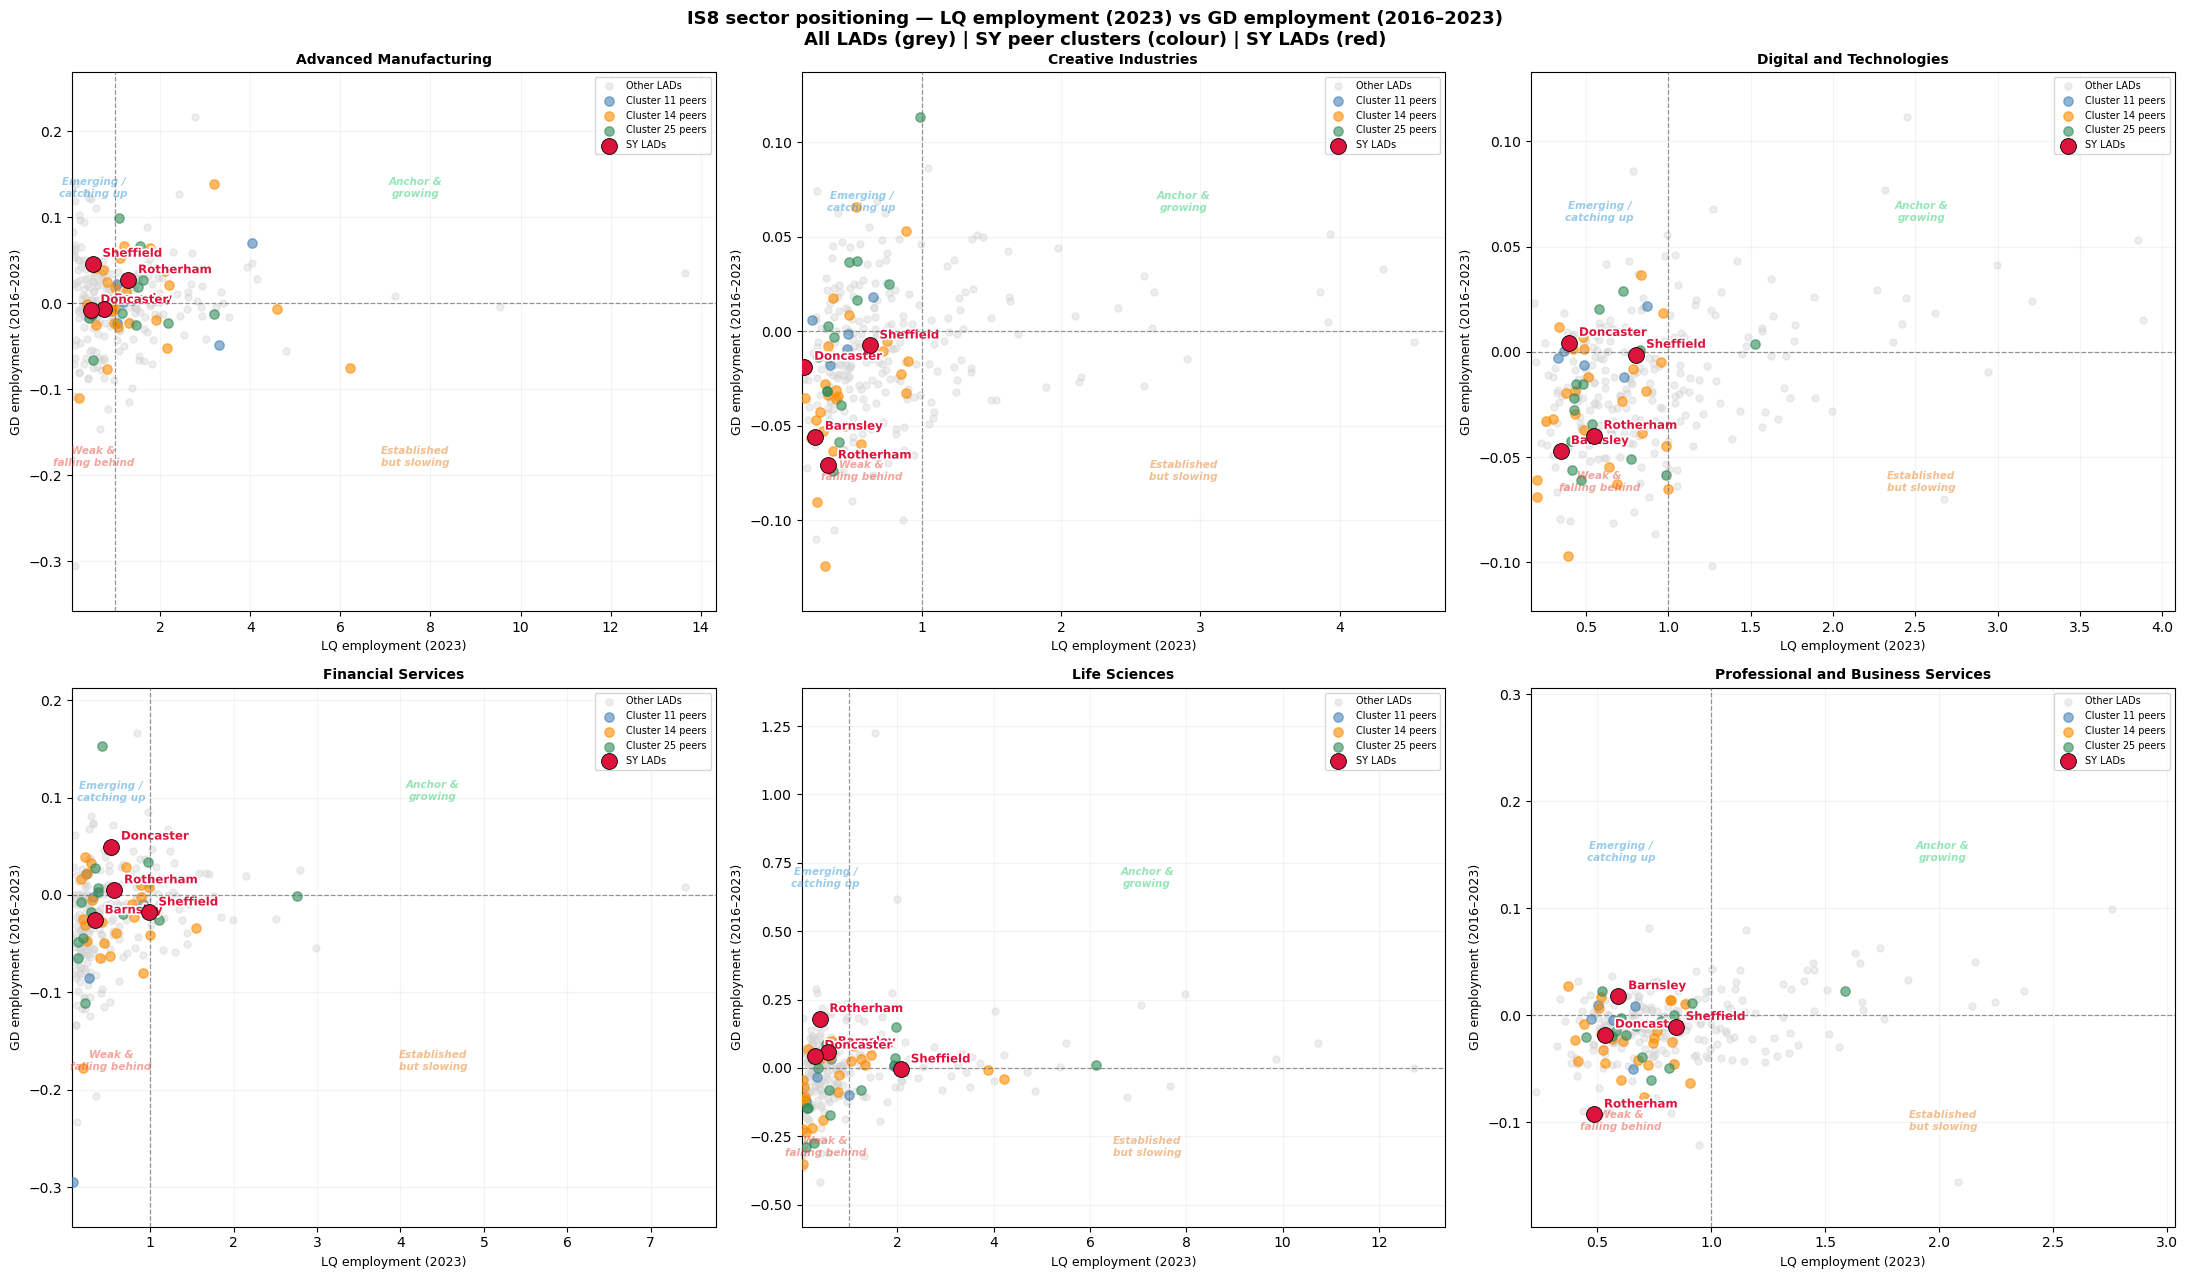

Saved: ../../output/graphs/franco/quadrant_national_lq_emp_vs_gd_emp.png


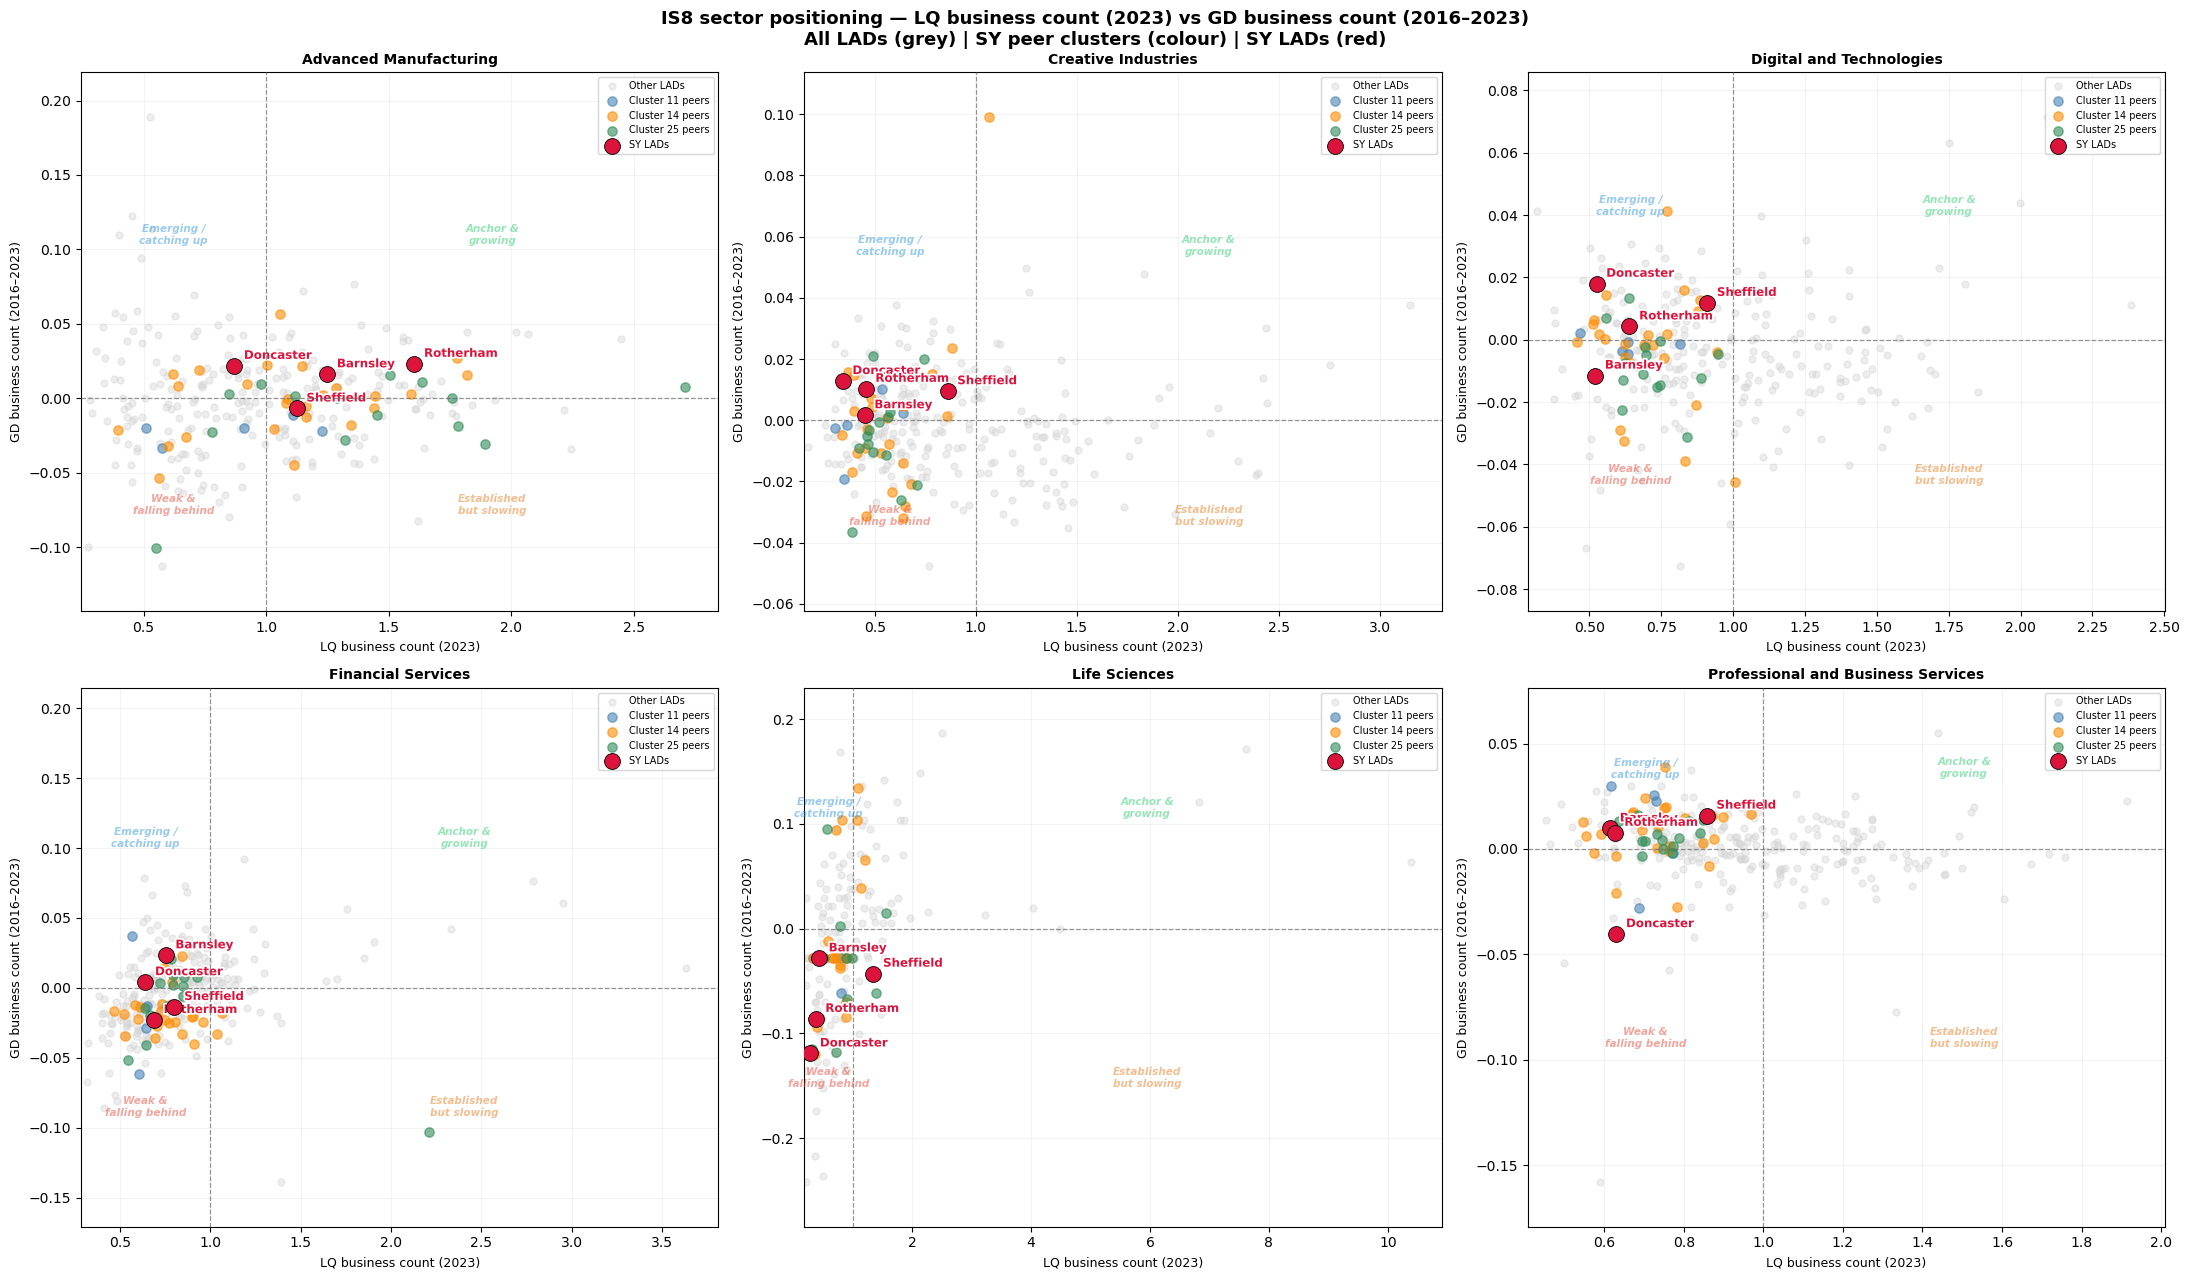

Saved: ../../output/graphs/franco/quadrant_national_lq_bus_vs_gd_bus.png


In [30]:
# ============================================================
# CELL 5c — IS8 sector quadrant positioning (national context)
#
# Plots LQ (x) vs GD (y) for all 279 LADs.
# Non-SY-peer LADs: light grey background
# SY peer cluster LADs: cluster colours
# SY LADs: red
# Quadrant boundaries: LQ=1, GD=0
# 2×3 grid — one panel per IS8 sector.
# Runs twice: once for emp, once for bus.
# ============================================================

METRIC_PAIRS = [
    ("lq_emp", "gd_emp",
     f"LQ employment ({YEAR})", f"GD employment (2016–{YEAR})"),
    ("lq_bus", "gd_bus",
     f"LQ business count ({YEAR})", f"GD business count (2016–{YEAR})"),
]

QUADRANT_LABELS = {
    "Q1": ("Anchor &\ngrowing",        "top-right",    "#2ecc71"),
    "Q2": ("Emerging /\ncatching up",  "top-left",     "#3498db"),
    "Q3": ("Weak &\nfalling behind",   "bottom-left",  "#e74c3c"),
    "Q4": ("Established\nbut slowing", "bottom-right", "#e67e22"),
}

# Derive SY cluster IDs and colours dynamically
SY_CLUSTER_IDS   = sorted(lad_df.loc[lad_df.index.intersection(SY_CODES), "cluster"].unique())
cluster_colours  = {cid: c for cid, c in zip(SY_CLUSTER_IDS, ["steelblue", "darkorange", "seagreen"])}
sy_cluster_codes = lad_df[lad_df["cluster"].isin(SY_CLUSTER_IDS)].index.tolist()
all_lad_codes    = lad_df.index.tolist()

# Build lookup: GEOGRAPHY_CODE × IS8_SECTOR → all Y metrics
lq_gd = (
    panel[panel["YEAR"] == YEAR]
    .set_index(["GEOGRAPHY_CODE", "IS8_SECTOR"])
    [["GEOGRAPHY_NAME", "lq_emp", "lq_bus", "gd_emp", "gd_bus"]]
    .copy()
)

for lq_metric, gd_metric, lq_label, gd_label in METRIC_PAIRS:

    fig, axes = plt.subplots(2, 3, figsize=(22, 13))
    axes = axes.flatten()
    fig.suptitle(
        f"IS8 sector positioning — {lq_label} vs {gd_label}\n"
        "All LADs (grey) | SY peer clusters (colour) | SY LADs (red)",
        fontsize=13, fontweight="bold"
    )

    for ax, sector in zip(axes, FOCUS_SECTORS):

        sec_df = lq_gd.xs(sector, level="IS8_SECTOR").copy()
        sec_df = sec_df[sec_df.index.isin(all_lad_codes)]
        sec_df = sec_df.dropna(subset=[lq_metric, gd_metric])
        sec_df = sec_df[sec_df[lq_metric] > 0]

        lq_vals = sec_df[lq_metric].astype(float).values
        gd_vals = sec_df[gd_metric].astype(float).values
        codes   = sec_df.index.tolist()
        names   = sec_df["GEOGRAPHY_NAME"].tolist()
        is_sy   = np.array([c in SY_CODES for c in codes])
        is_peer = np.array([c in sy_cluster_codes and c not in SY_CODES
                            for c in codes])
        is_bg   = ~is_sy & ~is_peer

        # Background — all other LADs in grey
        ax.scatter(lq_vals[is_bg], gd_vals[is_bg],
                   color="lightgrey", alpha=0.4, s=25, zorder=1,
                   label="Other LADs")

        # SY peer cluster LADs by cluster colour
        for cid, colour in cluster_colours.items():
            cid_codes = lad_df[lad_df["cluster"] == cid].index.tolist()
            mask = np.array([c in cid_codes and c not in SY_CODES
                             for c in codes])
            if mask.sum() == 0:
                continue
            ax.scatter(lq_vals[mask], gd_vals[mask],
                       color=colour, alpha=0.6, s=45, zorder=3,
                       label=f"Cluster {cid} peers")

        # Reference lines — LQ=1 and GD=0
        ax.axvline(1.0, color="dimgrey", linewidth=0.9,
                   linestyle="--", alpha=0.7, zorder=4)
        ax.axhline(0.0, color="dimgrey", linewidth=0.9,
                   linestyle="--", alpha=0.7, zorder=4)

        # Axis limits
        x_min = min(lq_vals.min() * 0.9, 0.8)
        x_max = lq_vals.max() * 1.05
        y_pad = (gd_vals.max() - gd_vals.min()) * 0.1 or 0.01
        y_min = gd_vals.min() - y_pad
        y_max = gd_vals.max() + y_pad
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        # Quadrant labels
        mid_x_l = (x_min + 1.0) / 2
        mid_x_r = (1.0 + x_max) / 2
        mid_y_t = (0.0 + y_max) / 2
        mid_y_b = (y_min + 0.0) / 2
        for _, (qtxt, pos, col) in QUADRANT_LABELS.items():
            qx = mid_x_r if "right" in pos else mid_x_l
            qy = mid_y_t if "top"   in pos else mid_y_b
            ax.text(qx, qy, qtxt, ha="center", va="center",
                    fontsize=7.5, color=col, alpha=0.5,
                    style="italic", fontweight="bold")

        # SY LADs — on top
        sy_lq = lq_vals[is_sy]
        sy_gd = gd_vals[is_sy]
        sy_nm = [n for n, s in zip(names, is_sy) if s]
        ax.scatter(sy_lq, sy_gd, color="crimson", s=130,
                   zorder=6, edgecolors="black", linewidths=0.6,
                   label="SY LADs")
        for xi, yi, nm in zip(sy_lq, sy_gd, sy_nm):
            ax.annotate(nm, (xi, yi),
                        xytext=(7, 5), textcoords="offset points",
                        fontsize=8.5, color="crimson", fontweight="bold",
                        path_effects=[pe.withStroke(linewidth=2.5,
                                                    foreground="white")])

        ax.set_xlabel(lq_label, fontsize=9)
        ax.set_ylabel(gd_label, fontsize=9)
        ax.set_title(sector, fontsize=10, fontweight="bold")
        ax.grid(alpha=0.15)

        handles, labels = ax.get_legend_handles_labels()
        ax.legend(dict(zip(labels, handles)).values(),
                  dict(zip(labels, handles)).keys(),
                  fontsize=7, loc="upper right")

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/quadrant_national_{lq_metric}_vs_{gd_metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

## Narrative Structure

### 1. Opening: South Yorkshire's IS8 footprint is internally differentiated
Don't start with the MCA aggregate — start by establishing that SY is not one economy. The dendrogram already showed this: Sheffield clusters separately from Barnsley/Doncaster/Rotherham. Use this as the framing device. Everything that follows is structured around that internal differentiation.

---

### 2. Life Sciences — anchor in Sheffield, absent elsewhere

**Evidence chain:**
- 5c (emp): Sheffield above LQ=1, the other three compressed at bottom-left — weak and falling behind
- 5a (lq_emp): Sheffield above cluster trend, peers like Broxtowe and Halton show what's achievable
- 5b (lq_emp): Sheffield converts related variety, others don't despite similar variety values
- 5c (bus): Sheffield's firm base is contracting (CAGR bus negative) even as employment holds
- 5b (lq_bus): Barnsley/Doncaster/Rotherham have near-zero business count LQ — not just weak employment but virtually no firm base

**The argument:** Sheffield has an established Life Sciences anchor driven by the university and teaching hospitals — it overperforms relative to structural peers. The other three LADs have the industrial diversity to support Life Sciences (related variety is there) but no firm base and no employment trajectory. The barrier is institutional: without an anchor organisation to seed the ecosystem, related variety alone doesn't convert.

---

### 3. Advanced Manufacturing — present but fragmented, positive momentum

**Evidence chain:**
- 5a (lq_emp): SY LADs broadly on trend — performing as structural position predicts
- 5a (lq_bus): Rotherham and Barnsley above trend on business count — more firms than structural position would suggest
- 5b (lq_bus): All four on or above trend — related variety is converting into firm presence
- 5c (bus): All four above cluster medians on CAGR bus — firm counts growing
- 5c (emp): Sheffield and Doncaster in emerging quadrant, positive employment CAGR

**The argument:** Advanced Manufacturing is the most structurally grounded story. Firms are present in proportion to industrial diversity, employment is growing above national median, and business counts are increasing. The constraint is depth not presence — the gap between business LQ (1.69 MCA aggregate) and employment LQ (1.16) points to SME fragmentation. The adjacency to Clean Energy via the Humber supply chain is the forward-looking opportunity.

---

### 4. Digital & Technologies — high potential, systemic underconversion

**Evidence chain:**
- 5b (lq_emp): All four below trend despite sitting at high end of related variety — the clearest underperformance signal in the dataset
- 5b (cagr_emp): Barnsley and Rotherham below trend and negative — losing ground
- 5c (emp): Rotherham and Barnsley in weak/falling behind quadrant
- 5b (lq_bus): All four below trend on business count
- 5c (bus): Barnsley clearly negative CAGR bus, Doncaster and Rotherham marginally positive

**The argument:** Digital is the most analytically distinctive case. The related variety is there — SY's industrial base is cognitively adjacent to digital technologies — but none of the four LADs are converting it into either employment or firm presence. Unlike Life Sciences where Sheffield is an exception, here all four underperform. This points to a systemic barrier rather than an institutional gap: likely skills (level 3+ qualifications below national median) combined with absence of anchor digital employers to generate spinoffs and spillovers.

---

### 5. Why is potential unrealised? — the barriers synthesis

Draw from the correlate scorecard (Cell 3) once regression results are in, but you can already frame the hypotheses from the plots:

| Barrier | Sectors affected | Evidence |
|---|---|---|
| Absence of anchor institutions | Life Sciences (Barnsley/Doncaster/Rotherham) | Near-zero firm base despite related variety |
| Skills gap | Digital across all four | High related variety but no employment conversion |
| SME fragmentation | Advanced Manufacturing | Business LQ > employment LQ, no large firm anchors |
| Spatial dependency on Sheffield | Life Sciences, Digital | Sheffield overperforms, others don't — spillovers not reaching neighbouring LADs |

---

### 6. Adjacency argument — the forward-looking case

Two specific adjacencies supported by the data:

- **Advanced Manufacturing → Clean Energy**: firm base is growing, related variety is high, proximity to Humber offshore wind cluster. This is the strongest forward case.
- **Advanced Manufacturing → Digital**: Rotherham's above-trend business count LQ on Advanced Manufacturing combined with Doncaster's positive Digital CAGR bus suggests potential for technology adoption within manufacturing firms.

---

### Plot allocation for write-up

You don't need all 10 plots in the final piece. I'd select:

| Plot | Where it goes |
|---|---|
| 5c emp (quadrant) | Opening — overall positioning of 4 LADs |
| 5b lq_emp (related variety) | Life Sciences + Digital unrealised potential argument |
| 5a lq_bus (structural vs bus LQ) | Advanced Manufacturing fragmentation |
| 5c bus (quadrant) | Business dynamics — consolidation vs growth |

The other 6 support the analysis but don't need to appear in the written narrative directly.

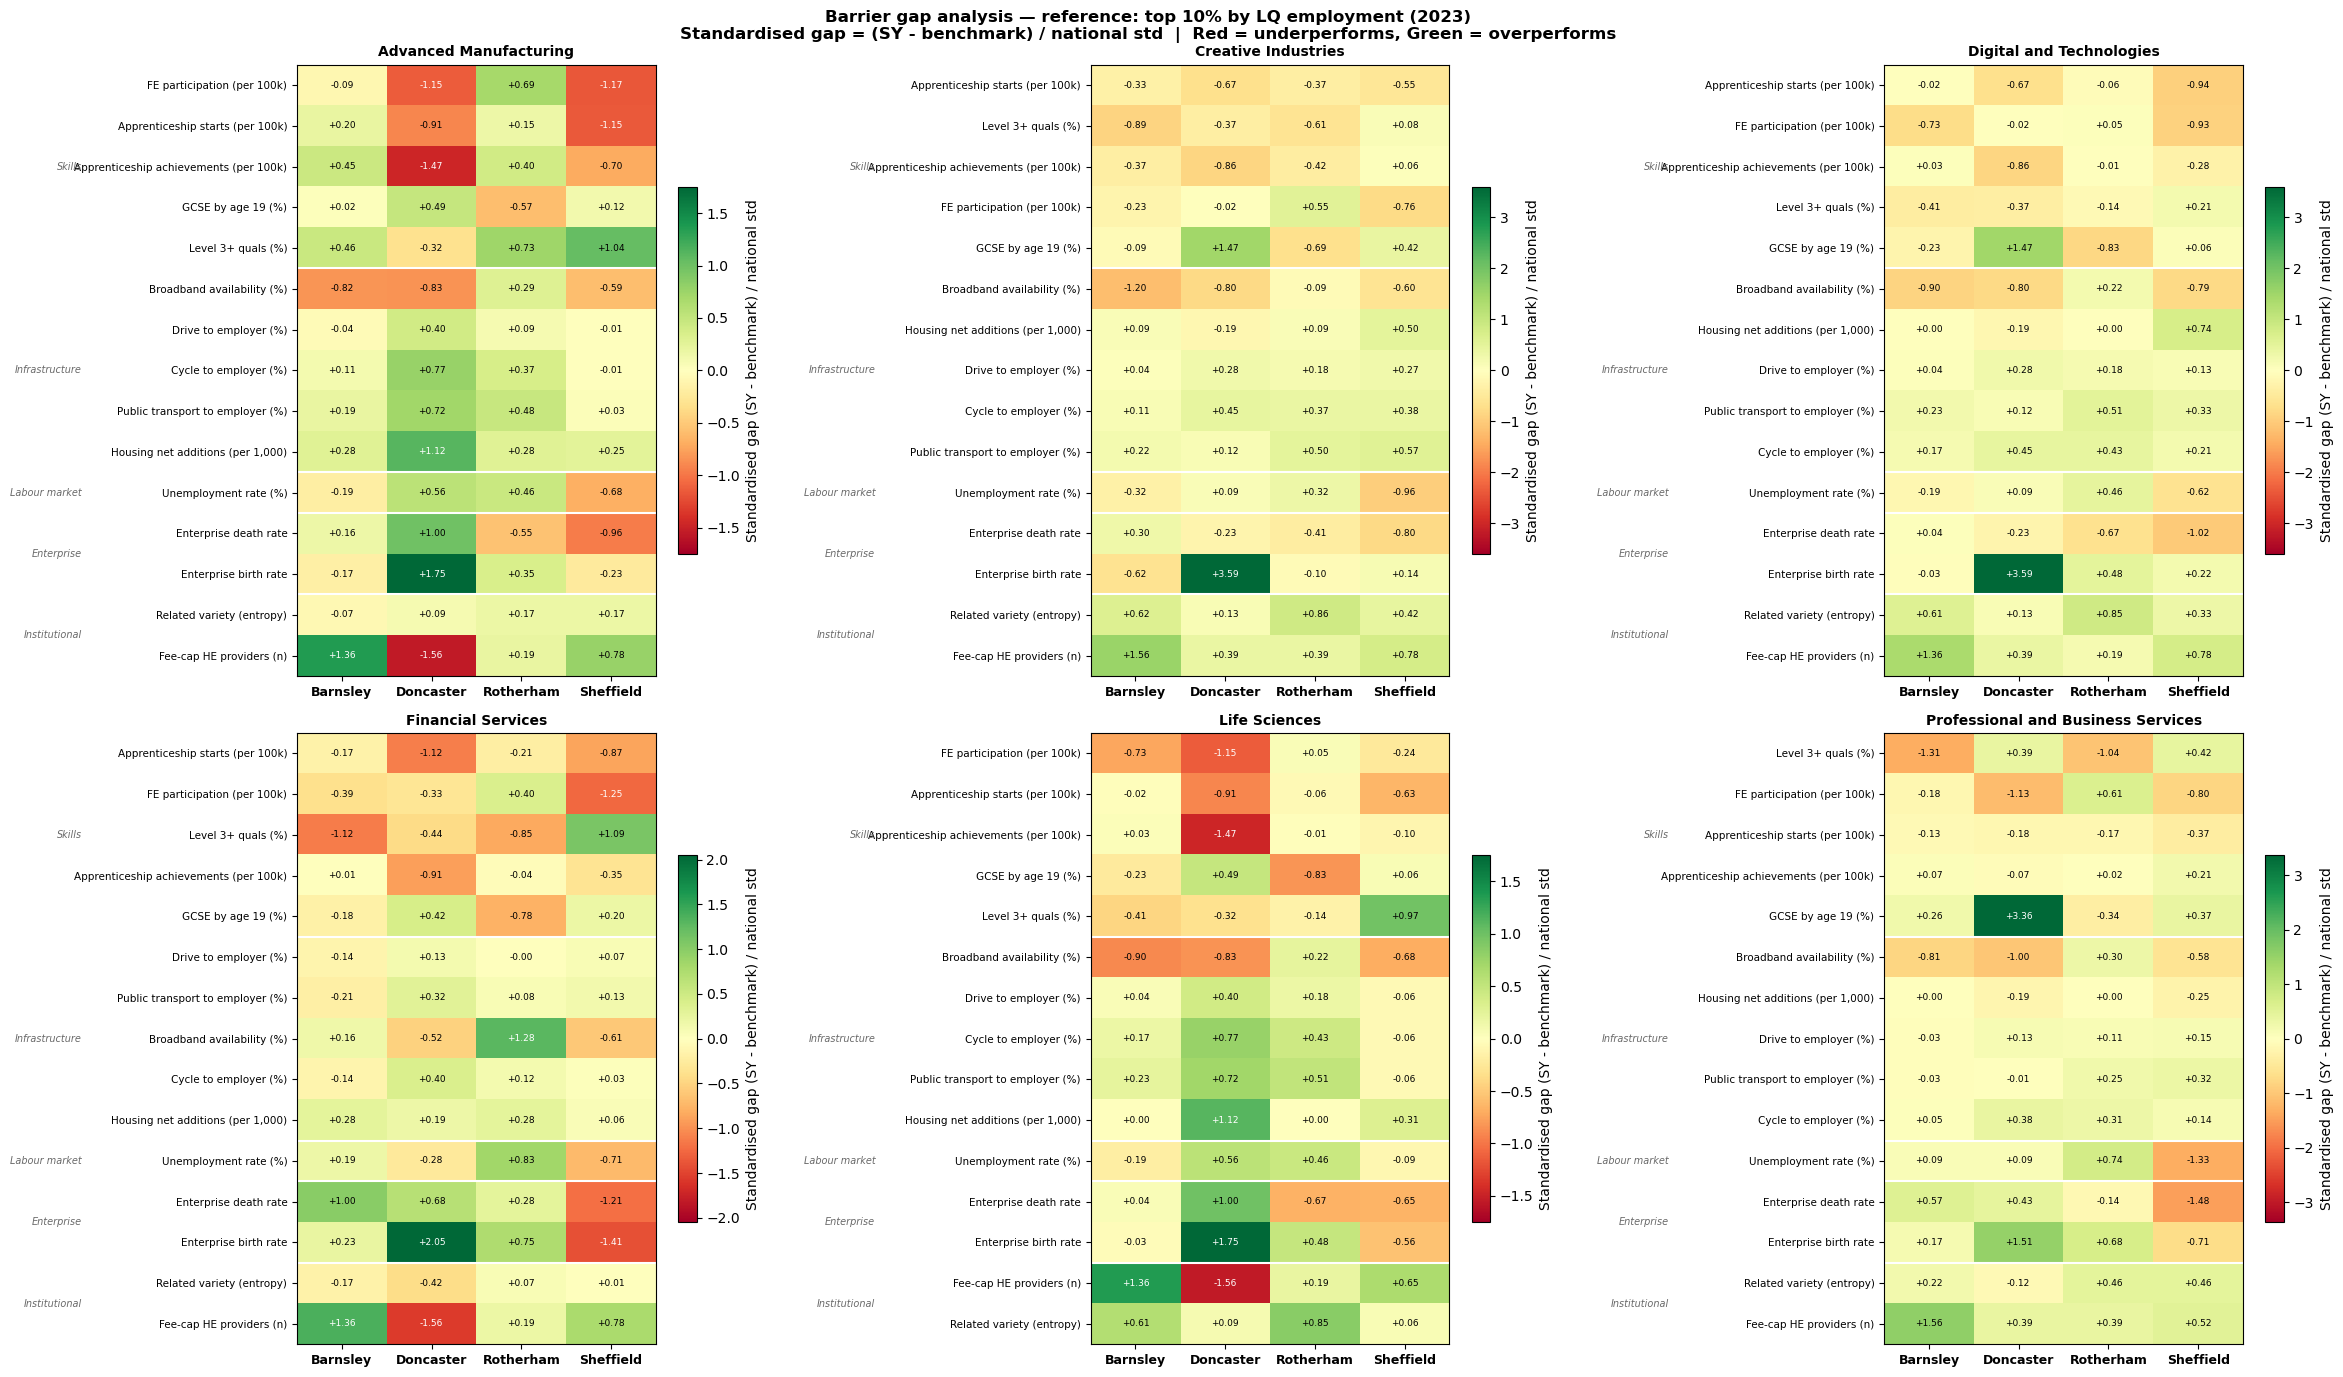

Saved: ../../output/graphs/franco/barrier_gap_lq_emp.png


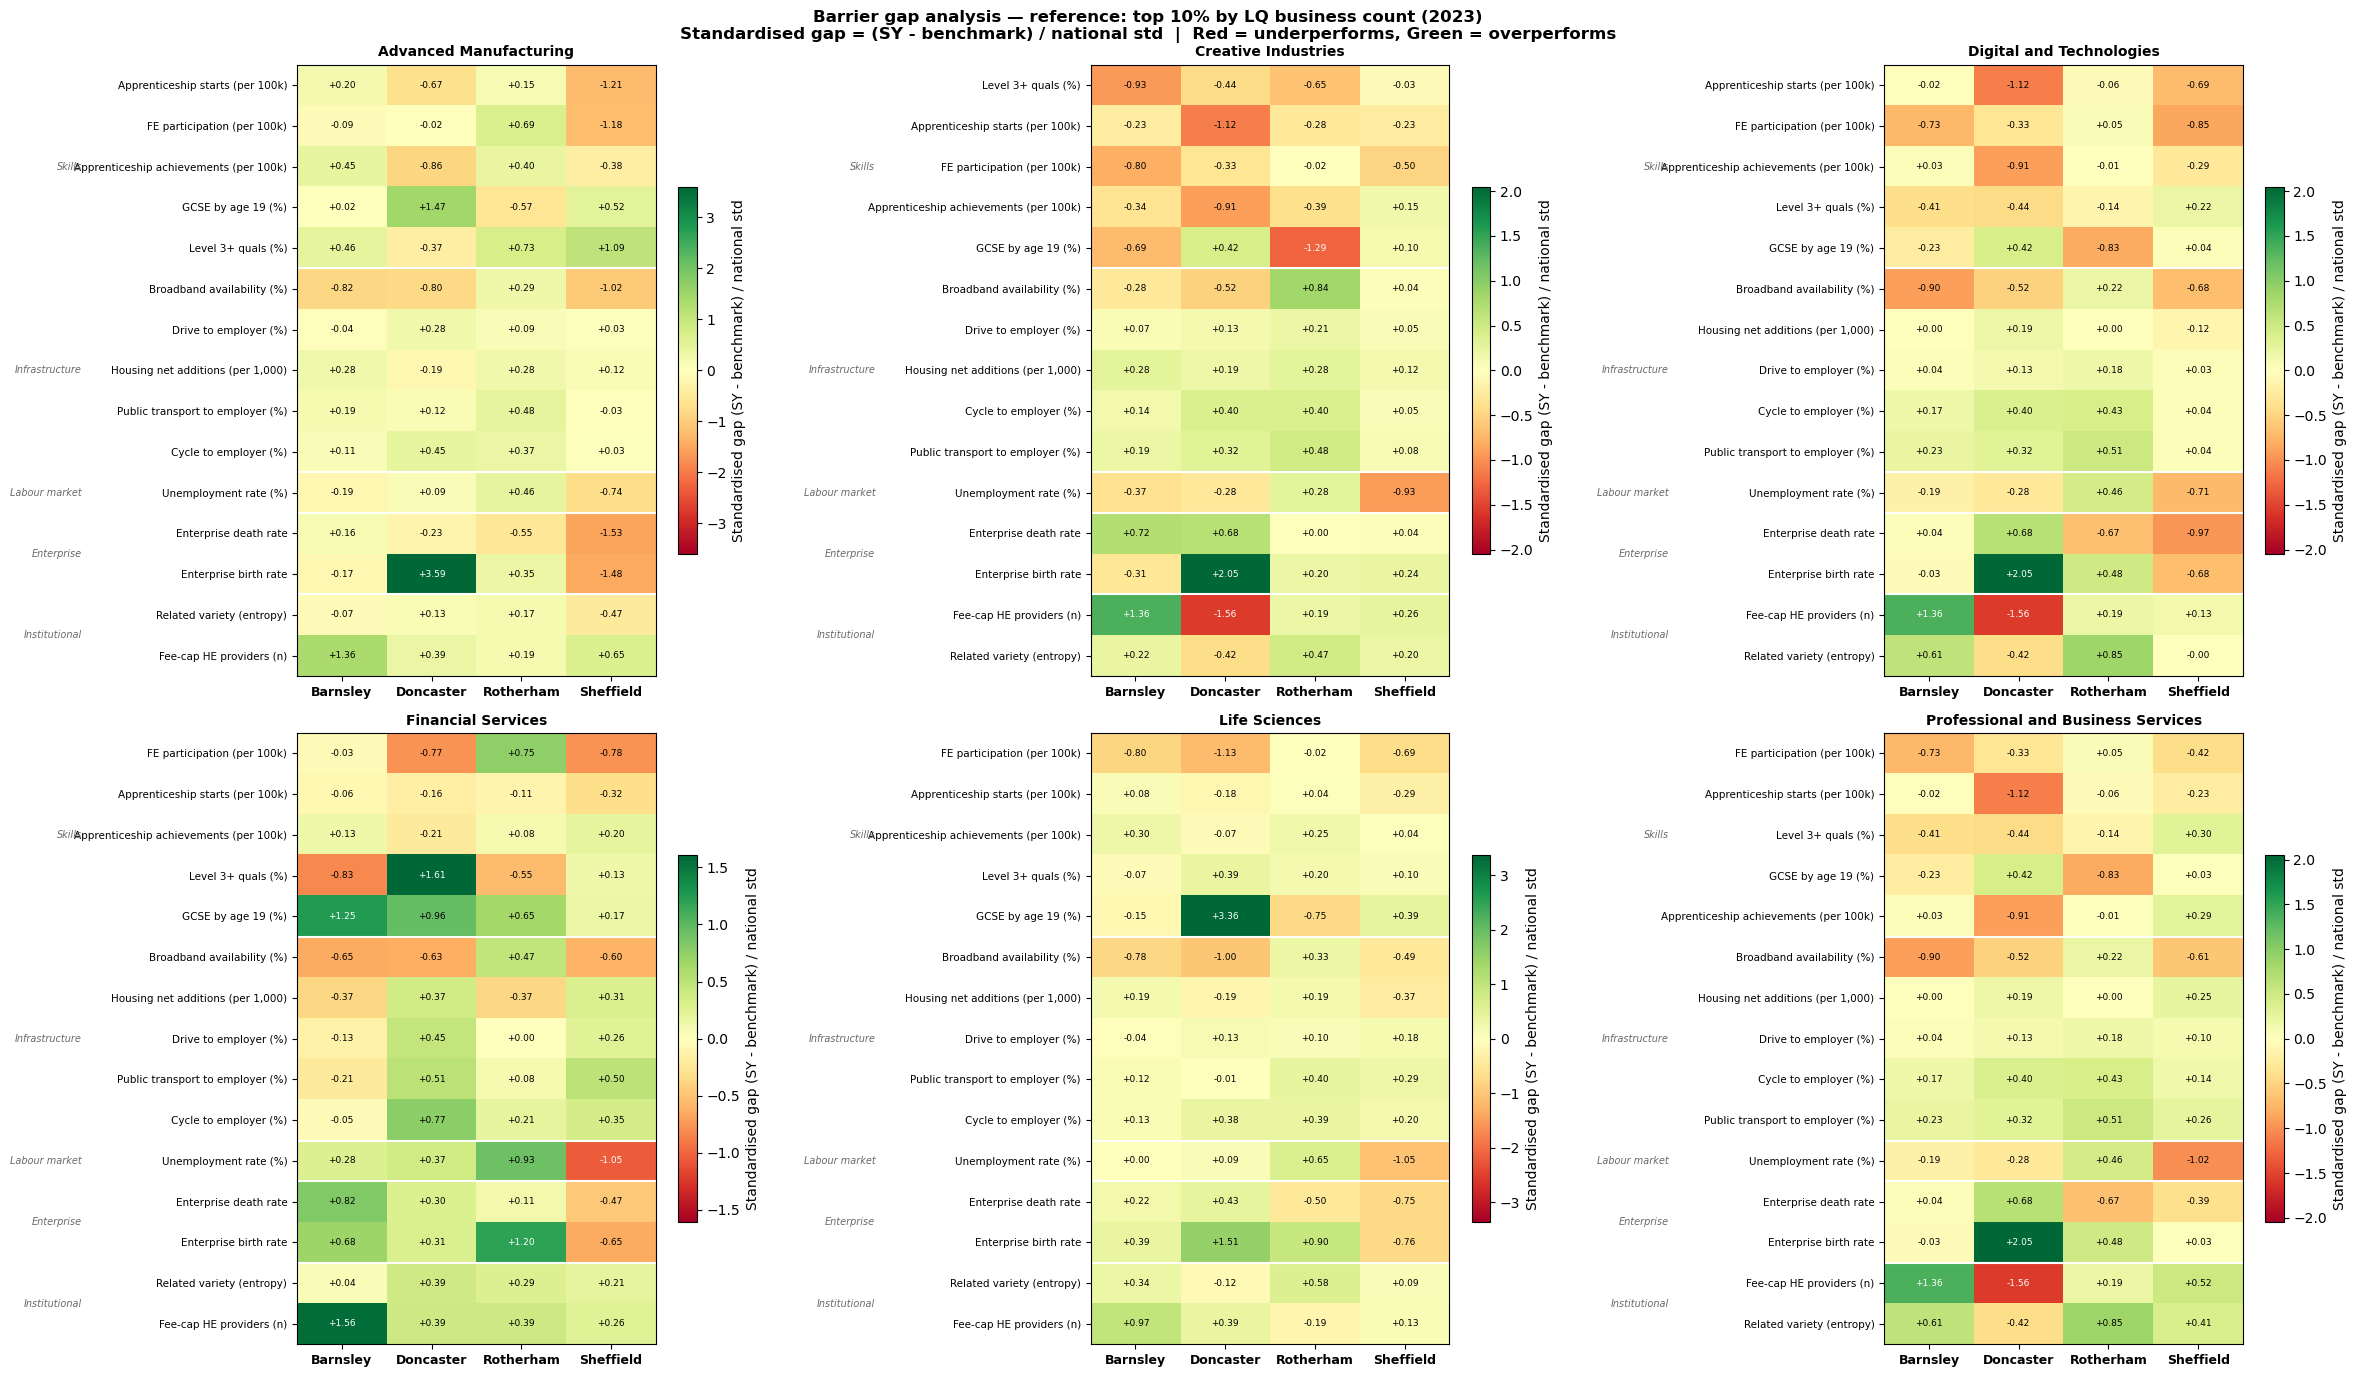

Saved: ../../output/graphs/franco/barrier_gap_lq_bus.png


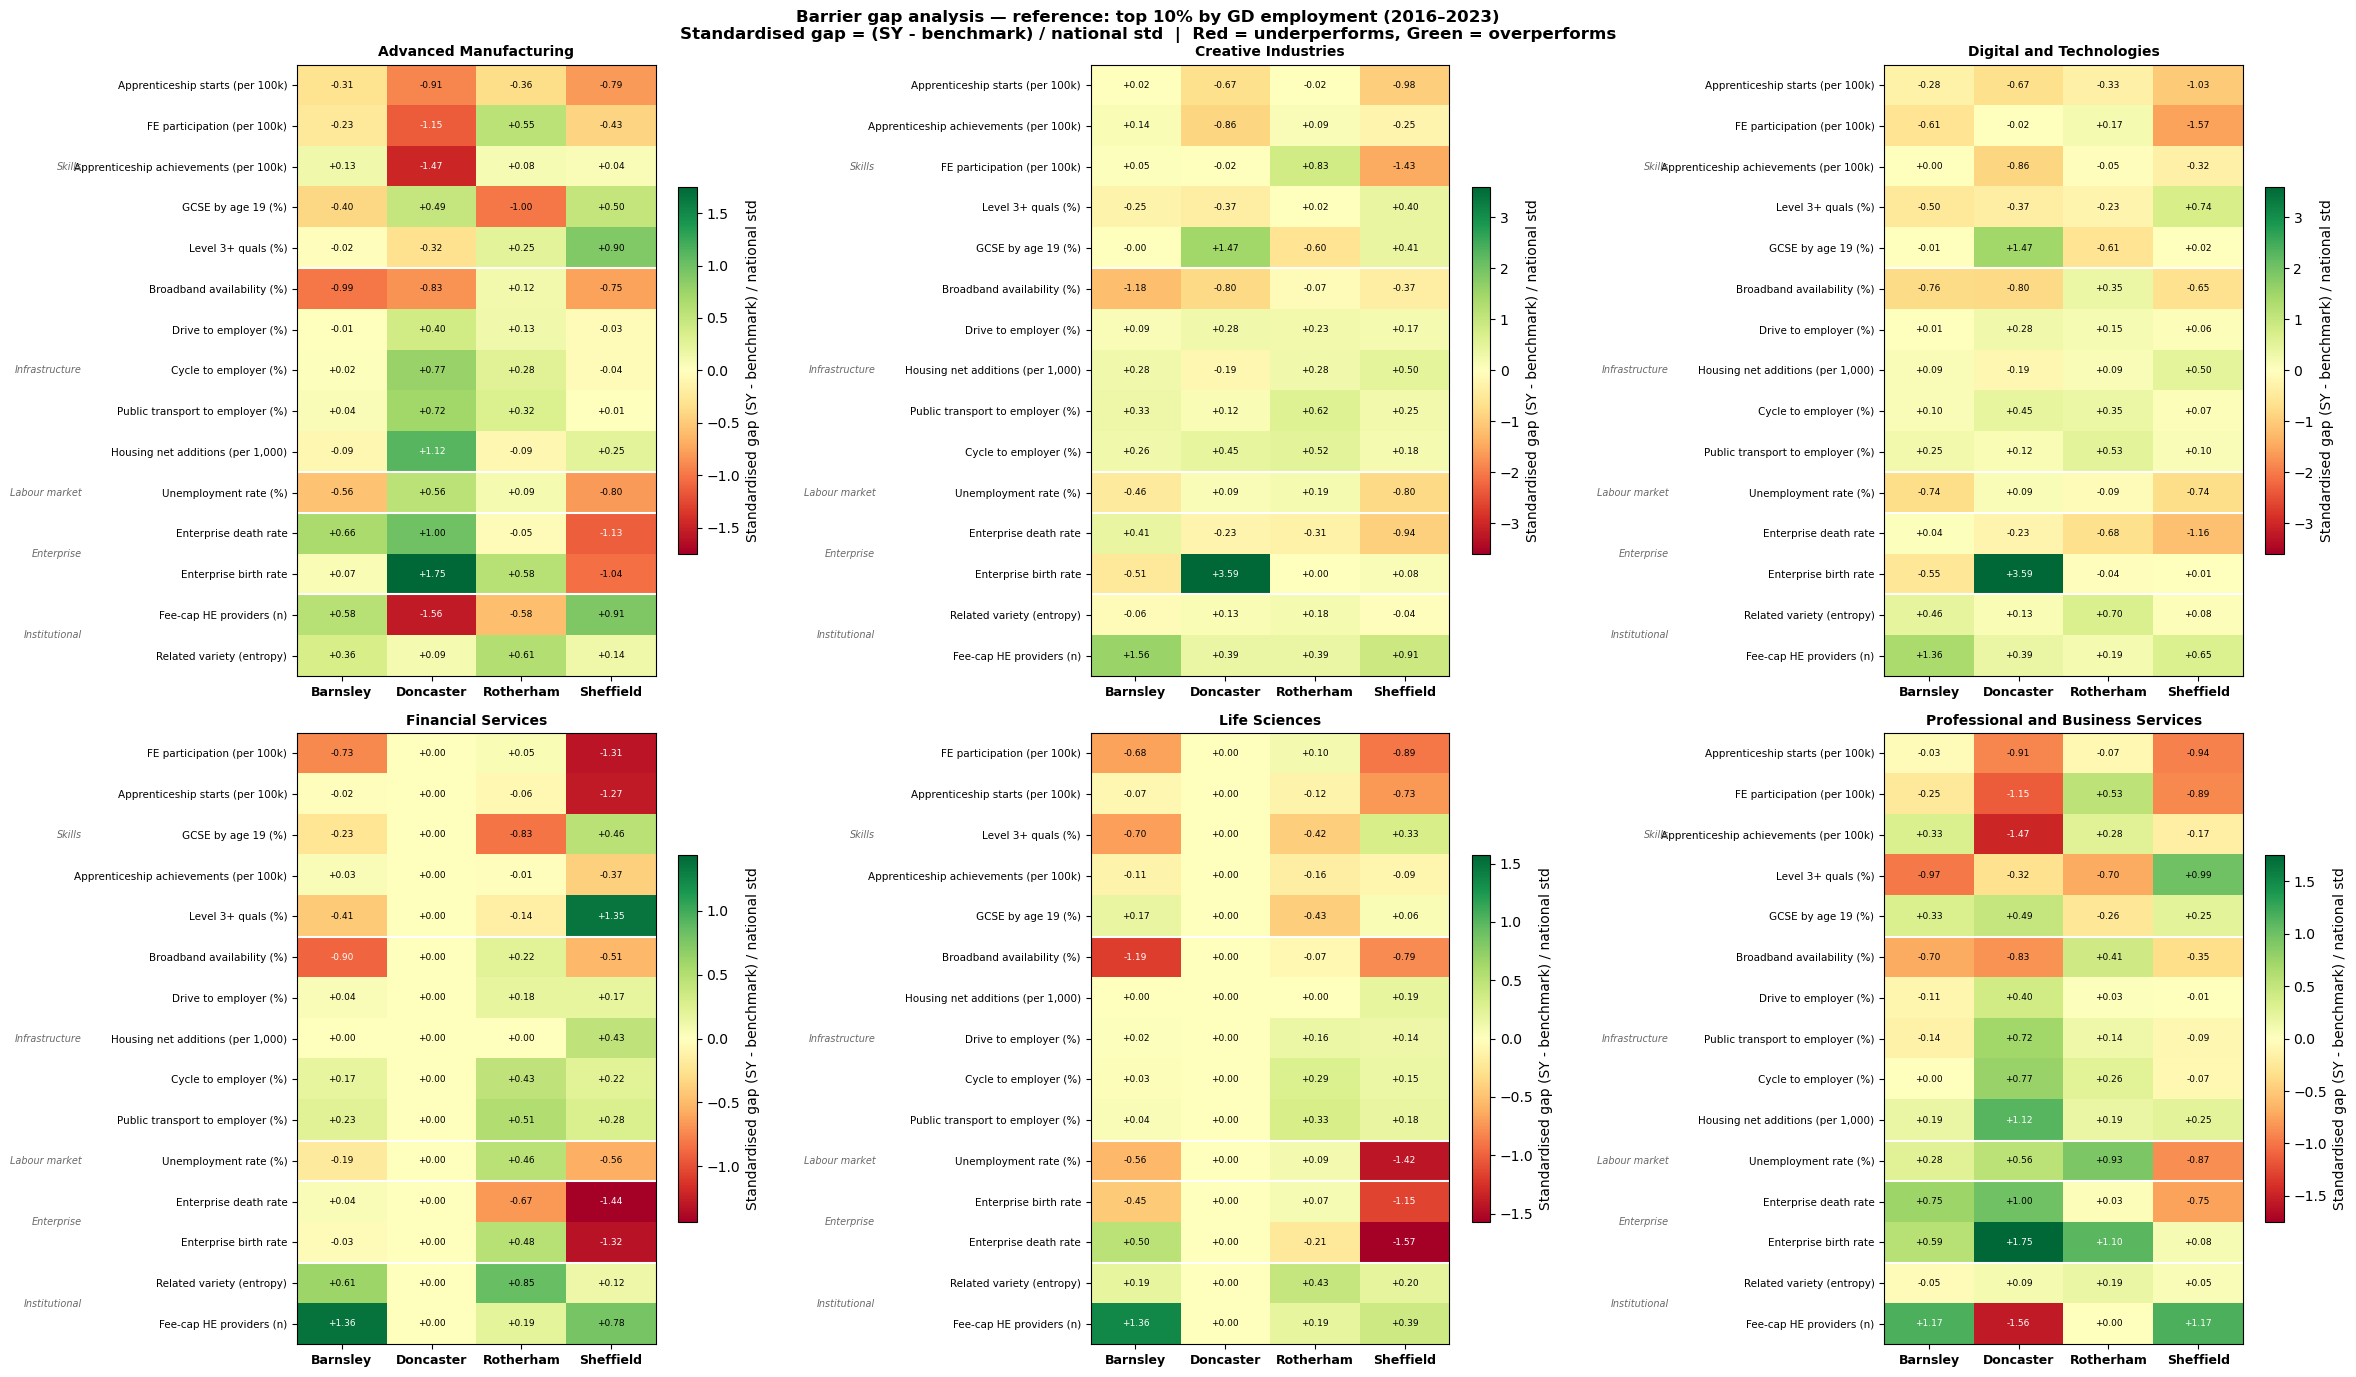

Saved: ../../output/graphs/franco/barrier_gap_gd_emp.png


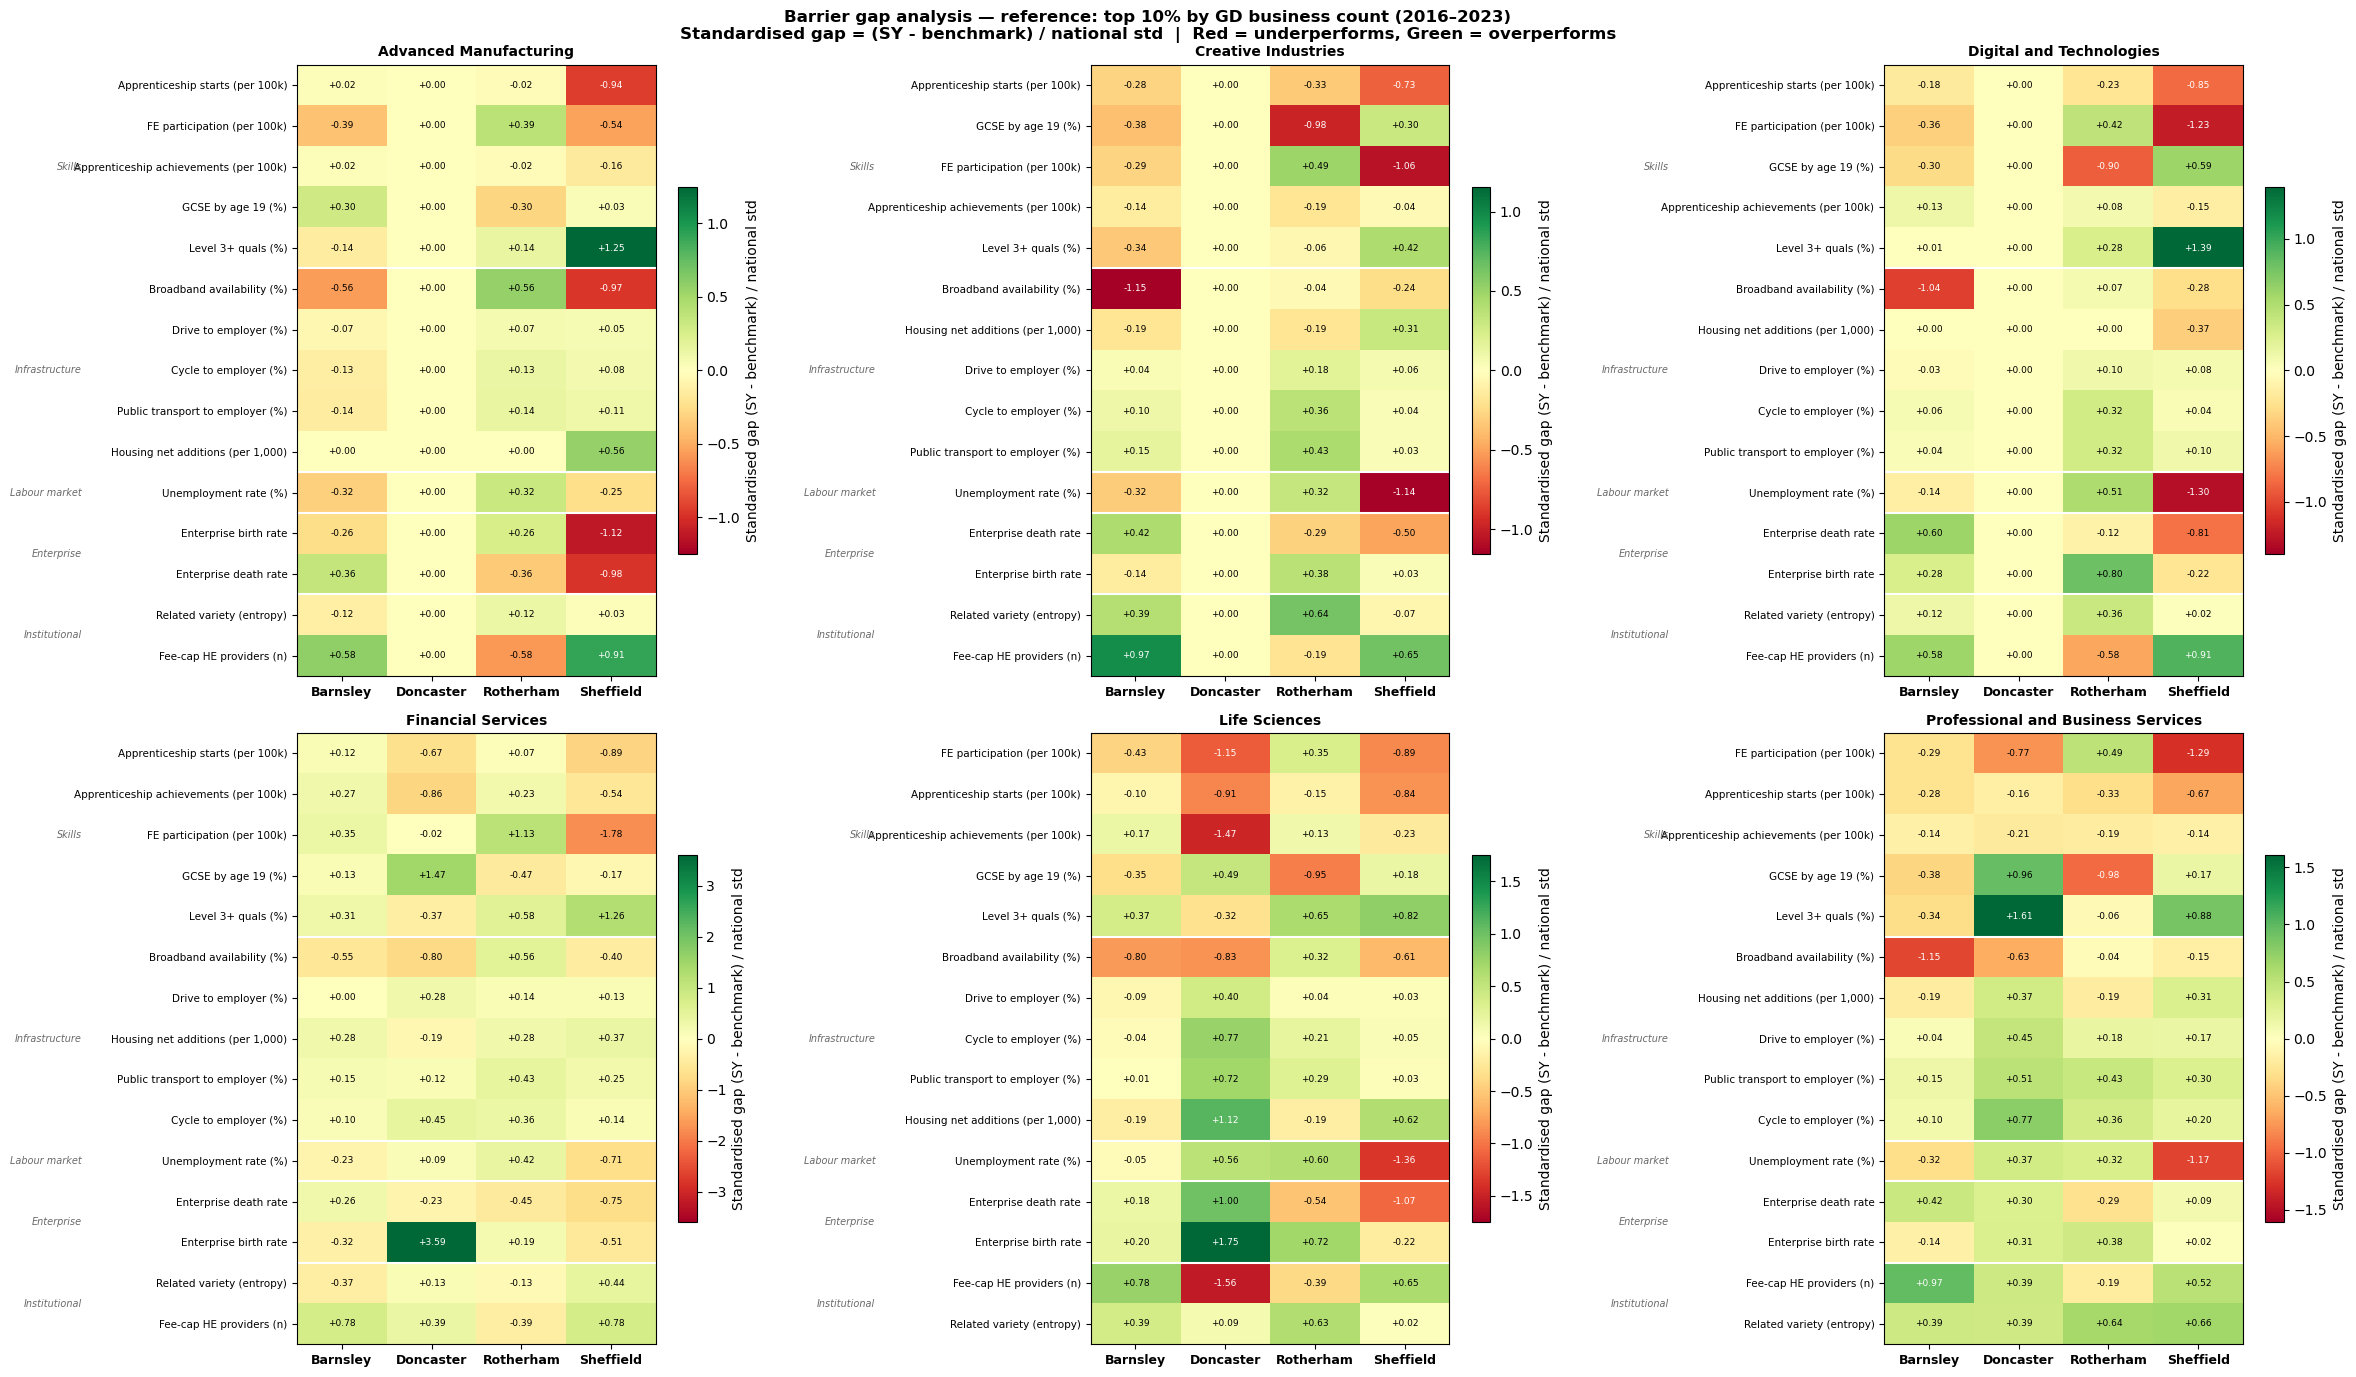

Saved: ../../output/graphs/franco/barrier_gap_gd_bus.png


In [32]:
# ============================================================
# CELL 6 — Barrier gap analysis
#
# For each SY LAD × sector × reference metric:
#   1. Find top 10% of LADs in SY LAD's cluster by that metric
#   2. Compute mean of those top performers on each barrier var
#   3. Gap = SY LAD value minus benchmark
#      Negative = SY underperforms → potential barrier
#      Positive = SY overperforms → not a constraint
#
# Output: one figure per reference metric (4 total)
#   2×3 grid — one panel per IS8 sector
#   Rows = barrier variables, Columns = 4 SY LADs
#   Colour = gap magnitude (red = under, green = over)
# ============================================================

BARRIER_VARS = {
    # Skills
    "nvq_level3":                  "Level 3+ quals (%)",
    "gcse_age19":                  "GCSE by age 19 (%)",
    "apprenticeship_starts":       "Apprenticeship starts (per 100k)",
    "apprenticeship_achievements": "Apprenticeship achievements (per 100k)",
    "fe_participation":            "FE participation (per 100k)",
    # Infrastructure
    "broadband":                   "Broadband availability (%)",
    "transport_to_employer":       "Public transport to employer (%)",
    "drive_to_employer":           "Drive to employer (%)",
    "cycle_to_employer":           "Cycle to employer (%)",
    # Housing
    "housing_net_additions":       "Housing net additions (per 1,000)",
    # Labour market
    "unemployment_rate":           "Unemployment rate (%)",
    # Enterprise
    "enterprise_birth_rate":       "Enterprise birth rate",
    "enterprise_death_rate":       "Enterprise death rate",
    # HE
    "n_universities_feecap_lad":   "Fee-cap HE providers (n)",
    # Diversity
    "related_variety":             "Related variety (entropy)",
}

BARRIER_GROUPS = {
    "Skills":         ["nvq_level3", "gcse_age19", "apprenticeship_starts",
                       "apprenticeship_achievements", "fe_participation"],
    "Infrastructure": ["broadband", "transport_to_employer",
                       "drive_to_employer", "cycle_to_employer",
                       "housing_net_additions"],
    "Labour market":  ["unemployment_rate"],
    "Enterprise":     ["enterprise_birth_rate", "enterprise_death_rate"],
    "Institutional":  ["n_universities_feecap_lad", "related_variety"],
}

REFERENCE_METRICS = [
    ("lq_emp",  f"LQ employment ({YEAR})"),
    ("lq_bus",  f"LQ business count ({YEAR})"),
    ("gd_emp",  f"GD employment (2016–{YEAR})"),
    ("gd_bus",  f"GD business count (2016–{YEAR})"),
]

SY_LAD_NAMES = {
    "E08000016": "Barnsley",
    "E08000017": "Doncaster",
    "E08000018": "Rotherham",
    "E08000019": "Sheffield",
}

# Derive cluster map dynamically
SY_CLUSTER_MAP = lad_df.loc[
    lad_df.index.intersection(SY_CODES), "cluster"
].to_dict()

# LAD-level barrier values — one row per LAD
barrier_df = (
    panel[panel["YEAR"] == YEAR]
    .drop_duplicates(subset="GEOGRAPHY_CODE")
    .set_index("GEOGRAPHY_CODE")
    [list(BARRIER_VARS.keys())]
    .copy()
)

# National std per variable — used to standardise gaps
nat_std = barrier_df.std(ddof=1).replace(0, np.nan)

# IS8 metric values per LAD × sector
metric_df = (
    panel[panel["YEAR"] == YEAR]
    .set_index(["GEOGRAPHY_CODE", "IS8_SECTOR"])
    [["lq_emp", "lq_bus", "gd_emp", "gd_bus"]]
    .copy()
)

for ref_metric, ref_label in REFERENCE_METRICS:

    fig, axes = plt.subplots(2, 3, figsize=(24, 14))
    axes = axes.flatten()
    fig.suptitle(
        f"Barrier gap analysis — reference: top 10% by {ref_label}\n"
        "Standardised gap = (SY - benchmark) / national std  |  Red = underperforms, Green = overperforms",
        fontsize=12, fontweight="bold"
    )

    for ax, sector in zip(axes, FOCUS_SECTORS):

        gap_records = []

        for sy_code, sy_name in SY_LAD_NAMES.items():
            cid = SY_CLUSTER_MAP.get(sy_code)
            if cid is None:
                continue
            cluster_codes = lad_df[lad_df["cluster"] == cid].index.tolist()

            # Metric values for cluster LADs in this sector
            try:
                sec_metrics = (
                    metric_df.xs(sector, level="IS8_SECTOR")[ref_metric]
                    .reindex(cluster_codes)
                    .dropna()
                )
            except KeyError:
                continue

            if len(sec_metrics) == 0:
                continue

            # Top 10% — at least 1 LAD
            n_top = max(1, int(np.ceil(len(sec_metrics) * 0.10)))
            top_codes = sec_metrics.nlargest(n_top).index.tolist()

            # Mean of top 10% on each barrier variable
            top_barrier = barrier_df.reindex(top_codes).mean()

            # SY LAD barrier values
            if sy_code not in barrier_df.index:
                continue
            sy_barrier = barrier_df.loc[sy_code]

            # Gap = (SY - benchmark) / national std
            raw_gap = sy_barrier - top_barrier
            gap = raw_gap / nat_std

            for var in BARRIER_VARS:
                if var in gap.index and pd.notna(gap[var]):
                    gap_records.append({
                        "lad":      sy_name,
                        "variable": var,
                        "gap":      float(gap[var]),
                    })

        if not gap_records:
            ax.set_title(f"{sector}\n(no data)", fontsize=9)
            ax.axis("off")
            continue

        gap_df  = pd.DataFrame(gap_records)
        pivot   = gap_df.pivot(index="variable", columns="lad", values="gap")

        # Order rows by group, then by mean gap (most negative first)
        ordered_vars = []
        group_boundaries = []
        for grp, vars_in_grp in BARRIER_GROUPS.items():
            valid = [v for v in vars_in_grp if v in pivot.index]
            if valid:
                valid_sorted = sorted(valid, key=lambda v: pivot.loc[v].mean())
                ordered_vars.extend(valid_sorted)
                group_boundaries.append((len(ordered_vars), grp))

        pivot = pivot.reindex(ordered_vars)
        pivot.index = [BARRIER_VARS[v] for v in ordered_vars]

        # Symmetric colour scale — normalised within panel
        abs_max = pivot.abs().max().max()
        if abs_max == 0:
            abs_max = 1

        im = ax.imshow(
            pivot.values,
            aspect="auto",
            cmap="RdYlGn",
            vmin=-abs_max,
            vmax=abs_max,
        )

        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, fontsize=9, fontweight="bold")
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=7.5)
        ax.set_title(sector, fontsize=10, fontweight="bold")

        # Cell values
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                if not np.isnan(val):
                    ax.text(j, i, f"{val:+.2f}",
                            ha="center", va="center",
                            fontsize=6.5,
                            color="black" if abs(val) < abs_max * 0.6
                            else "white")

        # Group separator lines and labels
        cum = 0
        for boundary, grp_name in group_boundaries[:-1]:
            ax.axhline(boundary - 0.5, color="white", linewidth=1.5)
        cum = 0
        for boundary, grp_name in group_boundaries:
            mid = (cum + boundary - 1) / 2
            ax.text(-0.6, mid, grp_name,
                    ha="right", va="center",
                    fontsize=7, color="dimgrey", fontstyle="italic",
                    transform=ax.get_yaxis_transform())
            cum = boundary

        plt.colorbar(im, ax=ax, shrink=0.6,
                     label="Standardised gap (SY - benchmark) / national std")

    plt.tight_layout()
    fname = f"{OUTPUT_DIR}/barrier_gap_{ref_metric}.png"
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fname}")

In [33]:
# ============================================================
# CELL 6b — Summary table: consistent barriers across metrics
#
# A variable flagged as negative (barrier) across all 4 metrics
# is a robust finding. This table counts how many times each
# variable × LAD × sector combination is in the red.
# ============================================================

print("\n=== ROBUST BARRIERS (negative gap in 3+ of 4 metrics) ===")
print("These variables consistently underperform against top performers\n")

all_gaps = []
for ref_metric, ref_label in REFERENCE_METRICS:
    for sector in FOCUS_SECTORS:
        for sy_code, sy_name in SY_LAD_NAMES.items():
            cid = SY_CLUSTER_MAP[sy_code]
            cluster_codes = lad_df[lad_df["cluster"] == cid].index.tolist()
            try:
                sec_metrics = (
                    metric_df.xs(sector, level="IS8_SECTOR")[ref_metric]
                    .reindex(cluster_codes).dropna()
                )
            except KeyError:
                continue
            if len(sec_metrics) == 0:
                continue
            n_top = max(1, int(np.ceil(len(sec_metrics) * 0.10)))
            top_codes = sec_metrics.nlargest(n_top).index.tolist()
            top_barrier = barrier_df.reindex(top_codes).mean()
            sy_barrier  = barrier_df.loc[sy_code] if sy_code in barrier_df.index else pd.Series(dtype=float)
            gap = sy_barrier - top_barrier
            for var in BARRIER_VARS:
                if var in gap.index and pd.notna(gap[var]):
                    all_gaps.append({
                        "metric": ref_metric, "sector": sector,
                        "lad": sy_name, "variable": var,
                        "gap": float(gap[var]), "negative": float(gap[var]) < 0
                    })

gaps_df = pd.DataFrame(all_gaps)
robust = (
    gaps_df.groupby(["sector", "lad", "variable"])["negative"]
    .sum()
    .reset_index()
    .rename(columns={"negative": "n_negative"})
)
robust = robust[robust["n_negative"] >= 3].sort_values(
    ["sector", "lad", "n_negative"], ascending=[True, True, False]
)
print(robust.to_string(index=False))


=== ROBUST BARRIERS (negative gap in 3+ of 4 metrics) ===
These variables consistently underperform against top performers

                            sector       lad                    variable  n_negative
            Advanced Manufacturing  Barnsley                   broadband           4
            Advanced Manufacturing  Barnsley           drive_to_employer           4
            Advanced Manufacturing  Barnsley            fe_participation           4
            Advanced Manufacturing  Barnsley           unemployment_rate           4
            Advanced Manufacturing  Barnsley       enterprise_birth_rate           3
            Advanced Manufacturing  Barnsley             related_variety           3
            Advanced Manufacturing Doncaster apprenticeship_achievements           3
            Advanced Manufacturing Doncaster       apprenticeship_starts           3
            Advanced Manufacturing Doncaster                   broadband           3
            Advanced Manu

**Barnsley — the most constrained LAD across all three sectors**

Five variables appear as robust barriers (n=4) across all sectors: `broadband_availability`, `4g_area_coverage`, `size_micro_share`, `unemployment_rate`, and `level_3+_qualifications` (on Life Sciences and Digital). Transport accessibility (`drive_to_employer`, `public_transport_to_employer`) also appears on Digital. This is a compound barrier profile — infrastructure, labour market, skills, and firm structure all constrain simultaneously. No single intervention fixes Barnsley.

**Doncaster — skills pipeline is the binding constraint**

`gcse_by_age_19` and `level_3+_qualifications` appear as n=4 across all three sectors. `apprenticeship_achievements` appears on Life Sciences and Advanced Manufacturing. `size_micro_share` appears on Life Sciences. The pattern is consistent — Doncaster's workforce qualification level is the primary gap relative to top performers in its cluster. Infrastructure is not an issue.

**Rotherham — moderate, skills-focused**

`gcse_by_age_19` is the most consistent barrier (n=4 on Advanced Manufacturing, Digital, Life Sciences). `apprenticeship_achievements` appears on Advanced Manufacturing and Digital. Broadband appears on Advanced Manufacturing and Digital but not Life Sciences. Rotherham is closer to its top performers than Barnsley or Doncaster — the gaps are smaller and less numerous.

**Sheffield — no barriers identified**

Method limitation as discussed.

---

**The synthesis across all three sectors and four LADs:**

| Variable | Barnsley | Doncaster | Rotherham | Type |
|---|---|---|---|---|
| Broadband availability | ✗✗✗ | — | partial | Infrastructure |
| 4G coverage | ✗✗✗ | — | — | Infrastructure |
| Transport accessibility | ✗✗ | — | — | Infrastructure |
| Unemployment rate | ✗✗✗ | — | partial | Labour market |
| Level 3+ qualifications | ✗✗✗ | ✗✗✗ | — | Skills |
| GCSE by age 19 | partial | ✗✗✗ | ✗✗✗ | Skills |
| Apprenticeship achievements | — | partial | partial | Skills |
| Size micro share | ✗✗✗ | partial | partial | Firm dynamics |

---

**The policy implication for the write-up:**

There are two distinct intervention logics depending on which LAD you're talking about:

For **Doncaster and Rotherham** the binding constraint is skills — specifically qualification attainment at GCSE and Level 3. These are solvable through FE investment and employer-led training programmes. The industrial base and infrastructure are adequate.

For **Barnsley** the barriers are structural and compound. Broadband and connectivity gaps mean IS8 firms won't locate there regardless of skills supply. The high micro-firm share and low large-firm share means there's no anchor employer to drive demand for higher skills. This requires infrastructure investment as a prerequisite, followed by firm attraction, before skills interventions become effective.

LADs with complete IS8 data (excl. Defence): 296


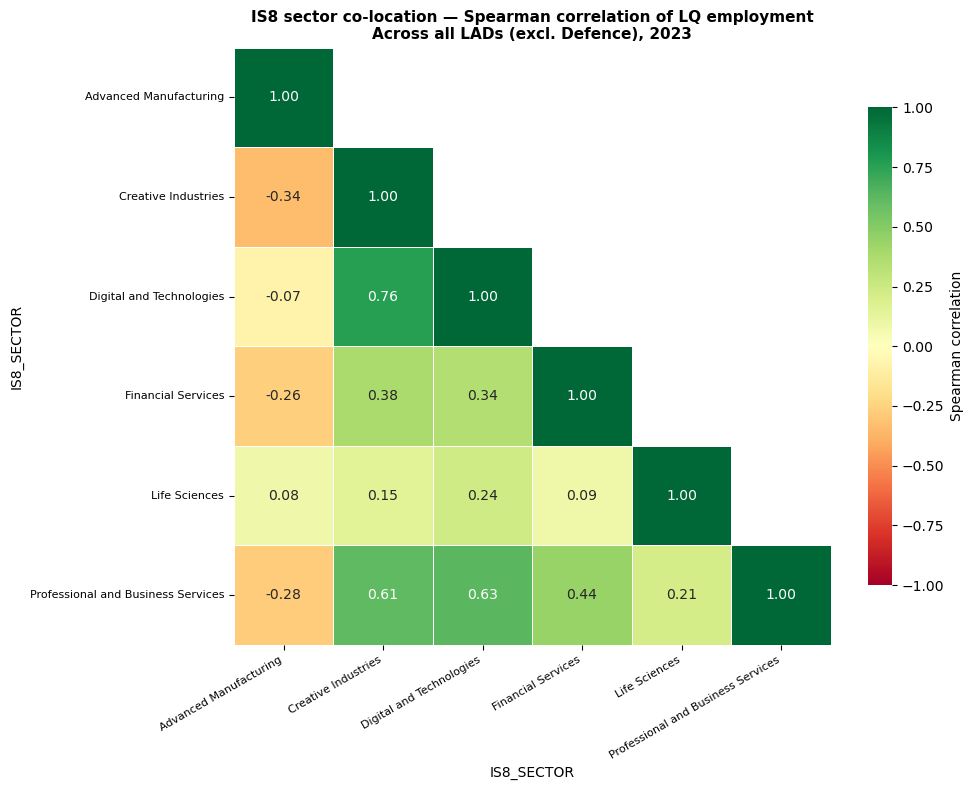

Saved: ../../output/graphs/franco/adjacency_correlation_matrix.png

=== CORRELATION RANKING FOR FOCUS SECTORS ===

Advanced Manufacturing — most correlated IS8 sectors:
  Life Sciences                                 r=+0.085
  Digital and Technologies                      r=-0.074
  Financial Services                            r=-0.262
  Professional and Business Services            r=-0.275
  Creative Industries                           r=-0.337

Creative Industries — most correlated IS8 sectors:
  Digital and Technologies                      r=+0.758
  Professional and Business Services            r=+0.609
  Financial Services                            r=+0.376
  Life Sciences                                 r=+0.152
  Advanced Manufacturing                        r=-0.337

Digital and Technologies — most correlated IS8 sectors:
  Creative Industries                           r=+0.758
  Professional and Business Services            r=+0.625
  Financial Services                  

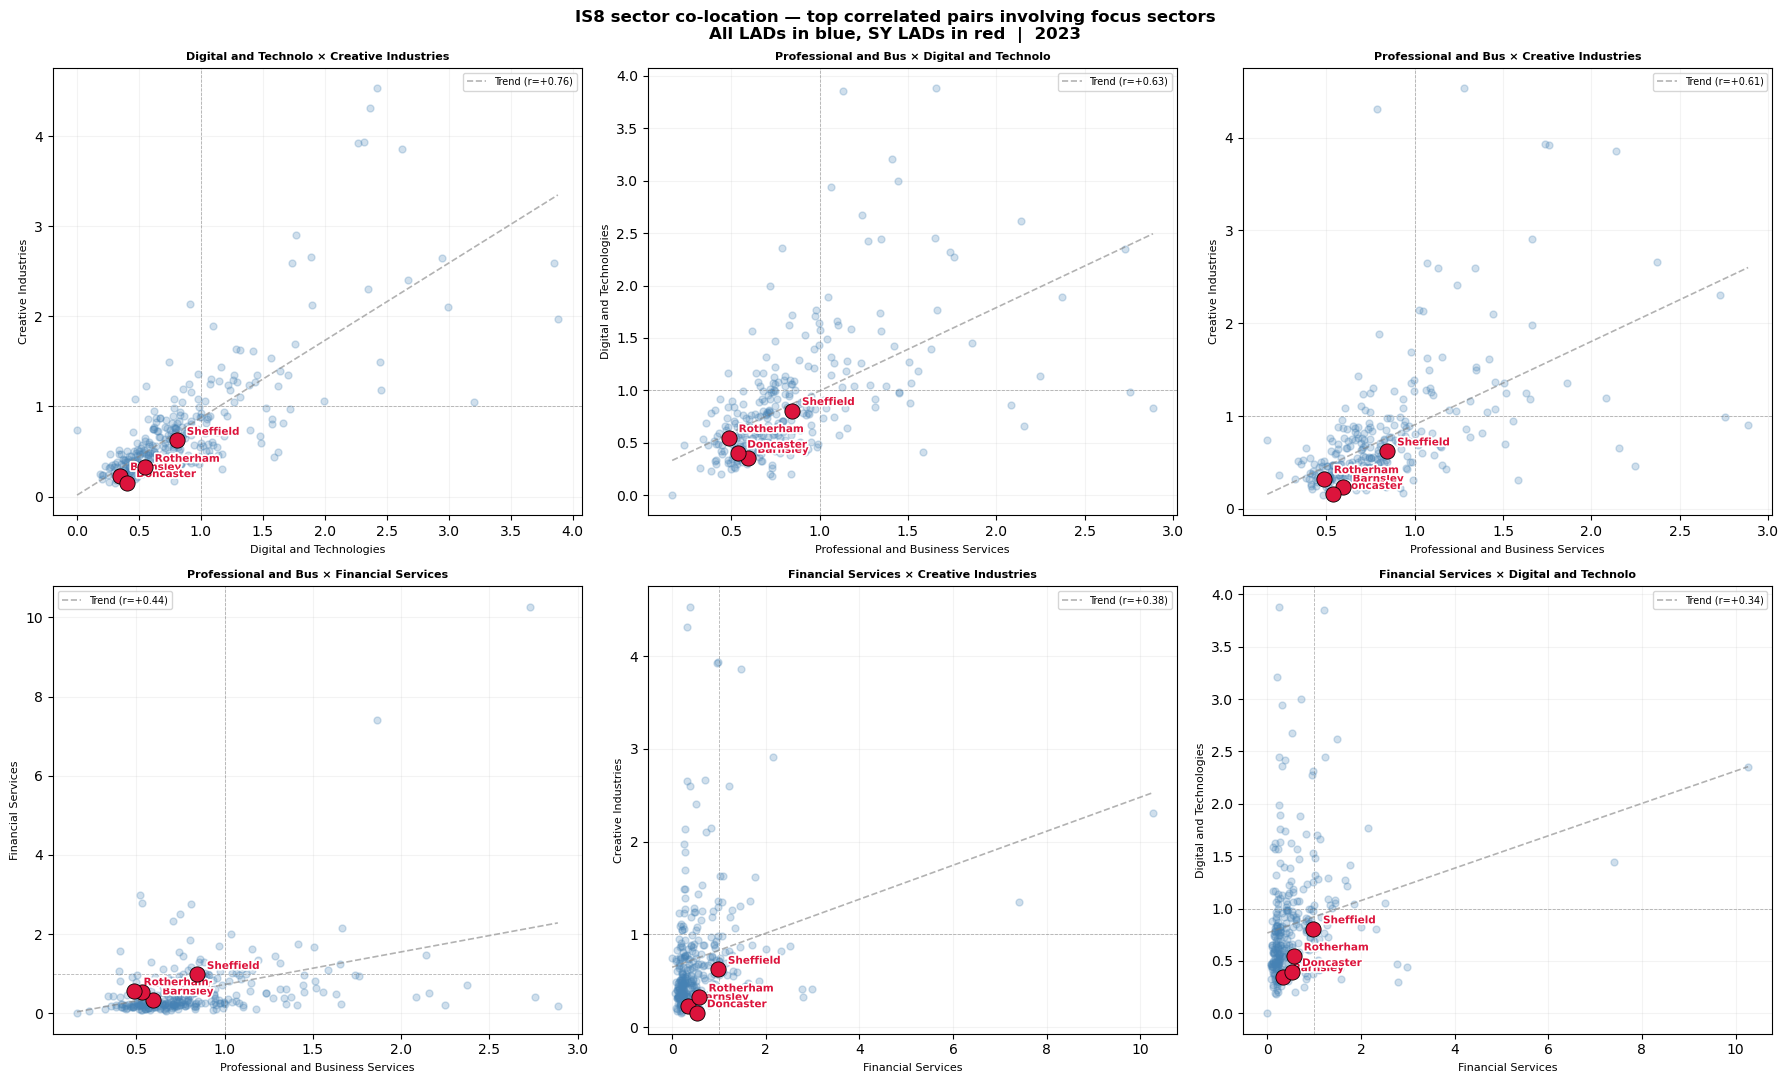

Saved: ../../output/graphs/franco/adjacency_scatter_pairs.png

=== SY ADJACENCY PROFILE ===
For each focus sector, SY's LQ on correlated IS8 sectors

--- Advanced Manufacturing ---
  Life Sciences                                 r=+0.085  SY LQ=0.83  ▼ below avg
  Digital and Technologies                      r=-0.074  SY LQ=0.53  ▼ below avg
  Financial Services                            r=-0.262  SY LQ=0.61  ▼ below avg
  Professional and Business Services            r=-0.275  SY LQ=0.61  ▼ below avg
  Creative Industries                           r=-0.337  SY LQ=0.33  ▼ below avg

--- Creative Industries ---
  Digital and Technologies                      r=+0.758  SY LQ=0.53  ▼ below avg
  Professional and Business Services            r=+0.609  SY LQ=0.61  ▼ below avg
  Financial Services                            r=+0.376  SY LQ=0.61  ▼ below avg
  Life Sciences                                 r=+0.152  SY LQ=0.83  ▼ below avg
  Advanced Manufacturing                        r=-0

In [34]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np
import pandas as pd
import seaborn as sns
import os

OUTPUT_DIR = "../../output/graphs/franco"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# CELL 7 — Cross-sector co-location adjacency analysis
#
# Step 1: Correlation matrix of IS8 sector LQs across all LADs
# Step 2: Scatter plots for the most relevant sector pairs
# Step 3: SY-specific adjacency profile
# ============================================================

SECTORS = [s for s in panel["IS8_SECTOR"].unique() if s != "Defence"]

# ── Step 1: Build wide LQ matrix (LAD × sector) ─────────────
lq_wide = (
    panel[panel["YEAR"] == YEAR]
    .pivot_table(index="GEOGRAPHY_CODE", columns="IS8_SECTOR", values="lq_emp")
    .drop(columns=["Defence"], errors="ignore")
    .dropna()
)

print(f"LADs with complete IS8 data (excl. Defence): {len(lq_wide)}")

# Spearman correlation — robust to outlier LQs
corr = lq_wide.corr(method="spearman")

# ── Plot 1: Correlation heatmap (lower triangle only) ────────
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    ax=ax,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Spearman correlation"},
)
ax.set_title(
    f"IS8 sector co-location — Spearman correlation of LQ employment\n"
    f"Across all LADs (excl. Defence), {YEAR}",
    fontsize=11, fontweight="bold"
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
fname = f"{OUTPUT_DIR}/adjacency_correlation_matrix.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

# Print correlation ranking for focus sectors
print("\n=== CORRELATION RANKING FOR FOCUS SECTORS ===")
for sector in FOCUS_SECTORS:
    print(f"\n{sector} — most correlated IS8 sectors:")
    ranked = corr[sector].drop(sector).sort_values(ascending=False)
    for s, r in ranked.items():
        print(f"  {s:<45} r={r:+.3f}")

# ── Step 2: Scatter plots for relevant pairs ─────────────────
pairs = []
for s1 in FOCUS_SECTORS:
    for s2 in SECTORS:
        if s2 == s1:
            continue
        r = corr.loc[s1, s2]
        pairs.append((abs(r), r, s1, s2))

pairs = sorted(pairs, reverse=True)
seen, top_pairs = set(), []
for _, r, s1, s2 in pairs:
    key = tuple(sorted([s1, s2]))
    if key not in seen:
        seen.add(key)
        top_pairs.append((r, s1, s2))
    if len(top_pairs) == 6:
        break

sy_lq_wide = lq_wide.reindex(SY_CODES).mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    f"IS8 sector co-location — top correlated pairs involving focus sectors\n"
    f"All LADs in blue, SY LADs in red  |  {YEAR}",
    fontsize=12, fontweight="bold"
)

for ax, (r, s1, s2) in zip(axes.flatten(), top_pairs):
    x_all = lq_wide[s1].values
    y_all = lq_wide[s2].values
    codes = lq_wide.index.tolist()
    names = (
        panel[panel["YEAR"] == YEAR]
        .drop_duplicates("GEOGRAPHY_CODE")
        .set_index("GEOGRAPHY_CODE")["GEOGRAPHY_NAME"]
        .reindex(codes)
        .values
    )
    is_sy = np.array([c in SY_CODES for c in codes])

    ax.scatter(x_all[~is_sy], y_all[~is_sy],
               color="steelblue", alpha=0.25, s=25, zorder=2)

    z = np.polyfit(x_all, y_all, 1)
    xl = np.linspace(x_all.min(), x_all.max(), 200)
    ax.plot(xl, np.poly1d(z)(xl), "--", color="grey", linewidth=1.2,
            alpha=0.6, zorder=3, label=f"Trend (r={r:+.2f})")

    for xi, yi, nm, sy in zip(x_all, y_all, names, is_sy):
        if not sy:
            continue
        ax.scatter(xi, yi, color="crimson", s=120, zorder=6,
                   edgecolors="black", linewidths=0.6)
        ax.annotate(nm, (xi, yi),
                    xytext=(7, 4), textcoords="offset points",
                    fontsize=7.5, color="crimson", fontweight="bold",
                    path_effects=[pe.withStroke(linewidth=2.5,
                                                foreground="white")])

    ax.axvline(1.0, color="dimgrey", linewidth=0.6,
               linestyle="--", alpha=0.5)
    ax.axhline(1.0, color="dimgrey", linewidth=0.6,
               linestyle="--", alpha=0.5)
    ax.set_xlabel(s1, fontsize=8)
    ax.set_ylabel(s2, fontsize=8)
    ax.set_title(f"{s1[:20]} × {s2[:20]}", fontsize=8, fontweight="bold")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.15)

plt.tight_layout()
fname = f"{OUTPUT_DIR}/adjacency_scatter_pairs.png"
plt.savefig(fname, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fname}")

# ── Step 3: SY adjacency profile ─────────────────────────────
print("\n=== SY ADJACENCY PROFILE ===")
print("For each focus sector, SY's LQ on correlated IS8 sectors\n")

for sector in FOCUS_SECTORS:
    print(f"--- {sector} ---")
    ranked = corr[sector].drop(sector).sort_values(ascending=False)
    for s, r in ranked.items():
        sy_lq = sy_lq_wide.get(s, np.nan)
        above = "▲ above avg" if sy_lq > 1.0 else "▼ below avg"
        print(f"  {s:<45} r={r:+.3f}  SY LQ={sy_lq:.2f}  {above}")
    print()

**The correlation matrix — the big structural insight**

Advanced Manufacturing is **negatively correlated** with almost everything: Creative Industries (-0.32), Financial Services (-0.20), Professional & Business Services (-0.20). It's essentially orthogonal to the urban knowledge economy cluster. The only positive correlation is with Life Sciences (+0.13) — weak but notable.

Digital, Creative, Professional & Business Services and Financial Services form a tight urban cluster — correlations of 0.68–0.74 between them. These sectors co-locate in the same types of places: city centres, graduate economies, dense service sectors.

Life Sciences is the most independent sector — weak positive correlations with everything, no strong co-location pattern. It follows its own logic (proximity to research hospitals, universities, specific supply chains).

**The SY adjacency profile — the uncomfortable finding**

Every single entry is "▼ below avg". SY is below LQ=1 on every IS8 sector that correlates with its three focus sectors. This means SY doesn't currently have a strong adjacency base to leverage from within IS8 sectors.

But read it more carefully:

For **Life Sciences** the correlations are all weak (max r=+0.20) — Life Sciences doesn't strongly co-locate with anything. So the absence of adjacent IS8 sectors in SY doesn't really constrain Life Sciences development. Sheffield's anchor is driven by non-IS8 factors (university, NHS) not by IS8 adjacency.

For **Advanced Manufacturing** the correlations are all negative or near-zero. Advanced Manufacturing actively doesn't co-locate with the urban knowledge economy. SY's below-average scores on Creative, Financial, and Professional Services are therefore not barriers — they're irrelevant or even structurally expected for a manufacturing economy.

For **Digital & Technologies** the strong correlation with Creative Industries (r=+0.74) and Professional & Business Services (r=+0.68) is the critical finding. SY scores below average on both. This is the adjacency gap — Digital tends to grow where Creative and Professional services are already present, and SY is weak on both.

---

**The revised adjacency argument:**

| Focus sector | Key adjacency | SY position | Implication |
|---|---|---|---|
| Life Sciences | Weakly correlated with everything — location-independent | All adjacent sectors below avg — but doesn't matter | Sheffield's anchor is institutional not adjacency-driven |
| Advanced Manufacturing | Negatively correlated with urban knowledge economy — stands alone | Expected — manufacturing doesn't need creative/financial sectors nearby | Humber Clean Energy adjacency is the real argument, not IS8 cross-sector |
| Digital & Technologies | Strongly tied to Creative Industries (0.74) and Prof Services (0.68) | Both below avg in SY — genuine adjacency gap | Creative sector weakness is a binding constraint on Digital growth |

The most actionable finding is the Digital-Creative link. SY's Creative Industries LQ of 0.74 (employment) is directly implicated in the Digital underperformance. Investing in creative sector presence — particularly in Sheffield where it's least weak — could unlock Digital growth through the adjacency mechanism.

## Narrative Structure

### 1. Opening framing (1 paragraph)
South Yorkshire MCA is not one economy — the dendrogram showed this before we wrote a single sentence. Sheffield clusters separately from Barnsley, Doncaster and Rotherham. Everything that follows is structured around that internal differentiation. The MCA aggregate masks more than it reveals.

---

### 2. Current IS8 footprint (1 paragraph + table from Cell 1)
Present the footprint table. Three sectors above national average: Life Sciences (1.51), Professional & Business Services (1.09), Advanced Manufacturing (1.16 employment / 1.69 business count). The business count gap in Advanced Manufacturing signals SME fragmentation — many firms, limited depth. Defence absent. Creative Industries and Digital below average.

---

### 3. Trajectory — anchor, emerging, declining (1 paragraph + quadrant plots 5c)
- Life Sciences: growing strongly (CAGR 12.6%, well above national median) — anchor at MCA level, but driven entirely by Sheffield
- Advanced Manufacturing: employment growing above national median, business counts positive — momentum sector
- Digital & Technologies: employment declining below national median for Barnsley and Rotherham, Doncaster and Sheffield slightly positive — the most mixed picture
- Use the quadrant plots to show this visually

---

### 4. Internal differentiation — the LAD-level story (2 paragraphs + scatter plots 5a/5b)
This is the analytical contribution of Phase 2 over the regional picture.

**Paragraph 1 — Life Sciences:**
Sheffield (LQ 1.90) overperforms relative to its structural peer group — above the cluster trend line, converting related variety into sector presence. Barnsley, Doncaster and Rotherham sit at the bottom of their cluster despite similar related variety values. Peer comparators Broxtowe (LQ 7.66) and Halton (LQ 5.78) show what is achievable with similar structural conditions. The barrier is institutional — Sheffield has the University of Sheffield, Sheffield Hallam, and two major NHS trusts; the other three have none of these anchors.

**Paragraph 2 — Advanced Manufacturing and Digital:**
Advanced Manufacturing is performing broadly as structural position predicts — Rotherham slightly above trend, others on it. The SME fragmentation story is visible in the business count plots — firm presence is proportional to related variety but employment depth lags. Digital is the most analytically distinctive case: all four LADs sit at the high end of related variety nationally but none are converting it into employment or firm presence. The co-location analysis reveals why — Digital growth nationally is strongly tied to Creative Industries (r=+0.74) and Professional & Business Services (r=+0.68), and SY is below average on both.

---

### 5. Barriers — why is potential unrealised? (1-2 paragraphs + barrier heatmaps)
Draw directly from the robust barriers table. Two distinct intervention logics:

**Doncaster and Rotherham — skills pipeline:**
GCSE attainment and Level 3+ qualifications are robust barriers (n=4) across all three focus sectors. Apprenticeship achievements also appear consistently. The workforce qualification pipeline is the primary constraint. Infrastructure is adequate. These are addressable through FE investment and employer-led training, without requiring major capital expenditure.

**Barnsley — compound structural disadvantage:**
Broadband availability (-18 to -23pp gap), 4G coverage, transport accessibility, unemployment rate, and micro-firm dominance all appear simultaneously. This is a different order of problem. Infrastructure investment is a prerequisite before skills or firm attraction interventions can work — IS8 firms require connectivity as a basic condition of operation. The absence of large anchor employers creates a low-skill equilibrium trap: firms don't locate because skills are weak, skills don't develop because firms aren't there to demand them.

---

### 6. Adjacency — forward-looking positioning (1 paragraph)
Advanced Manufacturing does not co-locate with the urban knowledge economy — it is structurally independent. The adjacency argument for Advanced Manufacturing therefore lies outside IS8: the proximity to the Humber estuary, home to the UK's largest offshore wind installation base, creates a supply chain opportunity in Clean Energy. SY's existing Advanced Manufacturing capability in precision engineering and materials is directly applicable to wind turbine components, subsea infrastructure, and grid technology.

For Digital, the co-location analysis points to Creative Industries as the enabling adjacency. Sheffield's Creative LQ (0.85 employment, higher than the other three) makes it the most viable entry point for Digital cluster development within SY. Targeted support for creative-digital convergence in Sheffield — animation, digital media, software — could generate the spillover conditions that the EEG literature identifies as preconditions for broader digital sector growth.

---

### 7. Conclusion — sector prioritisation (1 short paragraph)
Three tiers of recommendation emerge from the analysis:
- **Consolidate**: Life Sciences in Sheffield — anchor is established, trajectory is strong, policy should deepen rather than seed
- **Develop**: Advanced Manufacturing across the MCA, with targeted Clean Energy adjacency via Humber — momentum is positive, SME fragmentation is the binding constraint
- **Invest to unlock**: Digital in Sheffield and Doncaster — related variety is present, Creative-Digital adjacency needs nurturing, skills gaps in Doncaster are addressable

Barnsley requires a different policy logic entirely — infrastructure investment before sector-specific interventions.

---

## Plot allocation for write-up

| Section | Plot |
|---|---|
| Footprint | Cell 1 table |
| Trajectory | 5c quadrant — lq_emp vs cagr_emp |
| Internal differentiation | 5b — related variety vs lq_emp (Life Sciences + Digital panels) |
| Fragmentation | 5a — structural vs lq_bus |
| Barriers | barrier_gap_lq_emp heatmap (one representative heatmap) + robust barriers table |
| Adjacency | adjacency_correlation_matrix + Digital×Creative scatter panel |